# LASSO and Ridge Regression for Inflation Forecasting
## Empirical Analysis with German Macroeconomic Data

**Seminar paper**: Current Topics in Econometrics
**Supervisor**: Prof. Bernhard Schipp | Technische Universität Dresden

---

**Outline:**
1. Data acquisition and preparation (ECB + Eurostat API)
2. Exploratory data analysis
3. Models: OLS, Ridge, LASSO
4. Cross-validation with TimeSeriesSplit (λ selection)
5. Comparison of results (MSE, RMSE)
6. Visualisations: coefficient paths, shrinkage plots

**Target variable (Y):** HICP inflation rate for Germany (YoY, in %)
**Predictors (X):** 33 macroeconomic indicators from 4 categories -> 155 features with lags (after the NaN filter)


In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import os, pathlib, sys
_ROOT = pathlib.Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_preparation import get_raw_data, print_truncation_info
from src.data_preprocessing import build_feature_matrix, prepare_splits, transform_to_yoy
from src.training import fit_all_models
from src.evaluation import (
    clark_west,
    compute_adaptive_oos, compute_compare_oos, compute_dm_tests,
    compute_giacomini_rossi,
    compute_horizon_analysis, compute_oos_predictions, compute_regime_analysis,
    compute_selection_stability, compute_single_split_inference,
    compute_stationarity_tests,
)
from src.reporting import (
    export_gr_table, export_horizons_table, export_inference_table,
    export_regime_table, export_results_table, export_sources_table,
    export_stationarity_table,
    fig_01_hvpi, fig_02_correlation, fig_02b_heatmap, fig_03_tscv,
    fig_04_forecast, fig_05_mse_comparison,
    fig_06_lasso_path, fig_07_ridge_path, fig_08_lasso_selection,
    fig_09_lasso_cv_path, fig_10_shrinkage,
    fig_11_rolling_rmse, fig_12_selection_stability, fig_13_horizons,
    fig_14_giacomini_rossi,
    print_summary, update_readmes,
)

config.setup_environment()
print("All libraries loaded. Project root:", _ROOT)

All libraries loaded. Project root: /Users/anton/Desktop/SoSe26/Oekonometrie_Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26


## 0. Data functions (ECB + Eurostat)
The data-acquisition and preprocessing functions now live in `src/data_preparation.py` and `src/data_preprocessing.py`. All further pipeline stages are in `src/` (training, evaluation, reporting, pipeline).

In [2]:
# All data functions imported from src/data_preparation.py:
# get_raw_data(), load_all_data(), transform_to_yoy(), build_feature_matrix()
print("Data functions defined (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).")

Data functions defined (load_all_data, get_raw_data, transform_to_yoy, build_feature_matrix).


## 1. Data acquisition and preparation

In [3]:
df_raw = get_raw_data(use_cache=True, verbose=True)
df_raw.head(3)

Raw data loaded from cache: /Users/anton/Desktop/SoSe26/Oekonometrie_Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26/data/raw/data_raw.csv


,HVPI,IP_Verarbeitendes_Gew,IP_Nahrungs_Genuss,IP_Textil_Leder,IP_Holz_Papier_Druck,IP_Mineraloel,IP_Chemie,IP_Pharma,IP_Metall_Grundstoffe,IP_Metallerzeugnisse,...,ALQ_Gesamt,ALQ_Maenner,ALQ_Frauen,ALQ_Kern_Ges,ALQ_Kern_M,ALQ_Kern_F,LCI_Lohnkosten_BN,LCI_Loehne_BN,LCI_Lohnkosten_Ind,LCI_Loehne_Ind
2000-01-01,78.5,70.9,83.3,0.0,0.0,110.8,90.5,43.6,96.9,65.1,...,8.2,7.8,8.6,8.1,7.6,8.8,58.7,56.9,58.2,56.9
2000-02-01,78.6,79.5,87.0,0.0,0.0,103.0,93.1,47.6,105.5,72.4,...,8.1,7.8,8.6,8.0,7.5,8.7,58.7,56.9,58.2,56.9
2000-03-01,78.6,88.7,96.9,0.0,0.0,109.7,98.2,50.8,116.8,80.4,...,8.1,7.7,8.5,8.0,7.5,8.6,58.7,56.9,58.2,56.9


In [4]:
df_yoy = transform_to_yoy(df_raw)
df_yoy.to_csv(config.DATA_PROCESSED)

X, y = build_feature_matrix(df_yoy, lags=config.LAGS, forecast_horizon=1,
                             test_months=config.TEST_MONTHS)
train_end = len(y) - config.TEST_MONTHS

print(f"Feature matrix:  {X.shape[0]} observations x {X.shape[1]} features")
print(f"Target variable: {len(y)} observations")
print(f"Period:          {y.index[0]:%Y-%m} - {y.index[-1]:%Y-%m}")
print(f"\nShare of NaN in X: {X.isna().mean().mean():.1%}")

Feature matrix:  261 observations x 155 features
Target variable: 261 observations
Period:          2002-01 - 2024-10

Share of NaN in X: 0.0%


In [5]:
print_truncation_info(df_raw, y)

Last valid observation per series (shortest first):
BS_Produktionserwart    2024-09-01
HVPI                    2025-12-01
ALQ_Frauen              2026-04-01
ALQ_Kern_Ges            2026-04-01
ALQ_Kern_M              2026-04-01
ALQ_Kern_F              2026-04-01
IP_Energie              2026-04-01
IP_Sonstiger_Fahrzeug   2026-04-01

Raw data up to:      2026-05
Feature matrix up to: 2024-10
Unused months:       19
Reason: shortest series in the list above determines the end date of the feature matrix.


### Sample extension

**Solution:** Eurostat delivered IP_* and PPI_* with `unit=I15` (base year 2015=100) only up to **2023-12**. The base year was updated to **I21 (2021=100)**, which gives identical index series with a different reference year.

**New data coverage after refresh:**

| Series group | Before | After |
|---|---|---|
| Industrial production (IP_*) | 2023-12 | **2026-04** |
| Producer prices (PPI_*) | 2023-12 | **2026-04** |
| HICP (target variable) | 2025-12 | 2025-12 |
| LCI (labour costs) | 2025-10 | 2025-10 |
| BS_Produktionserwart | 2024-09 | 2024-09 |

**New sample limit:** `BS_Produktionserwart` ends at 2024-09, so with lag 1 the last usable target point is around **2024-10** (+9 months relative to 2024-01).

**Consequence:** The test window now extends into the 2024 disinflation phase, which increases the external validity of the out-of-sample comparison.

**Methodological note:** The switch from I15 to I21 changes only the reference point, not the growth rates. This should be mentioned as a data-source footnote in the paper.

## 2. Exploratory data analysis

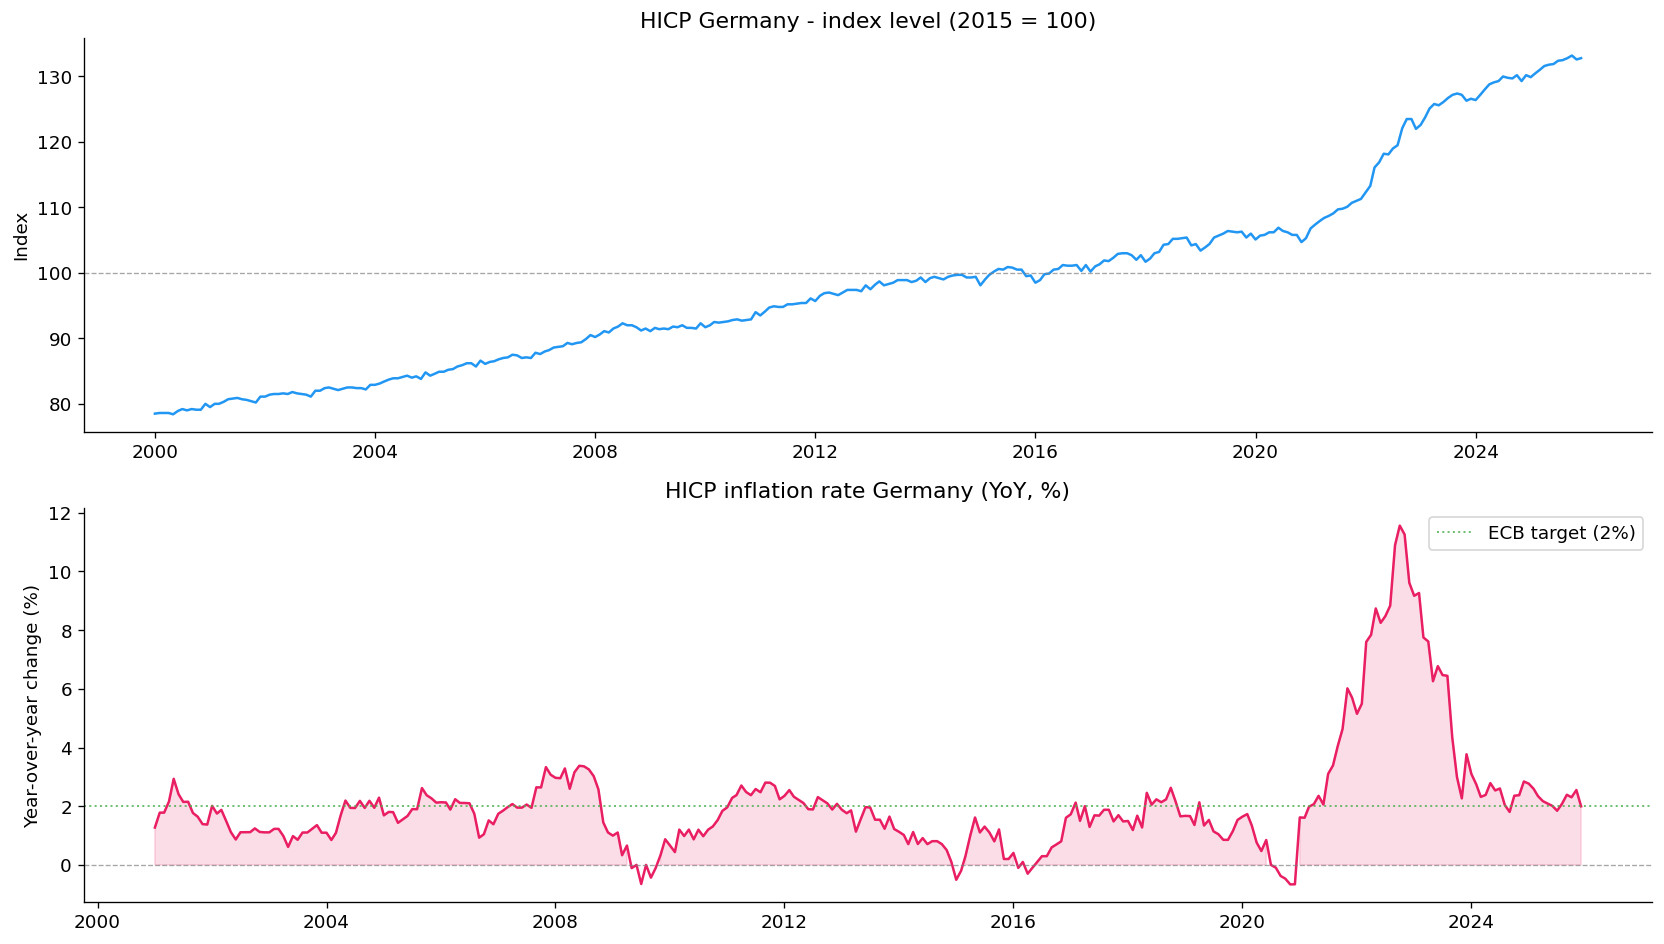

Figure saved: fig_01_hvpi_zeitreihe.png


In [6]:
fig_01_hvpi(df_raw, df_yoy)

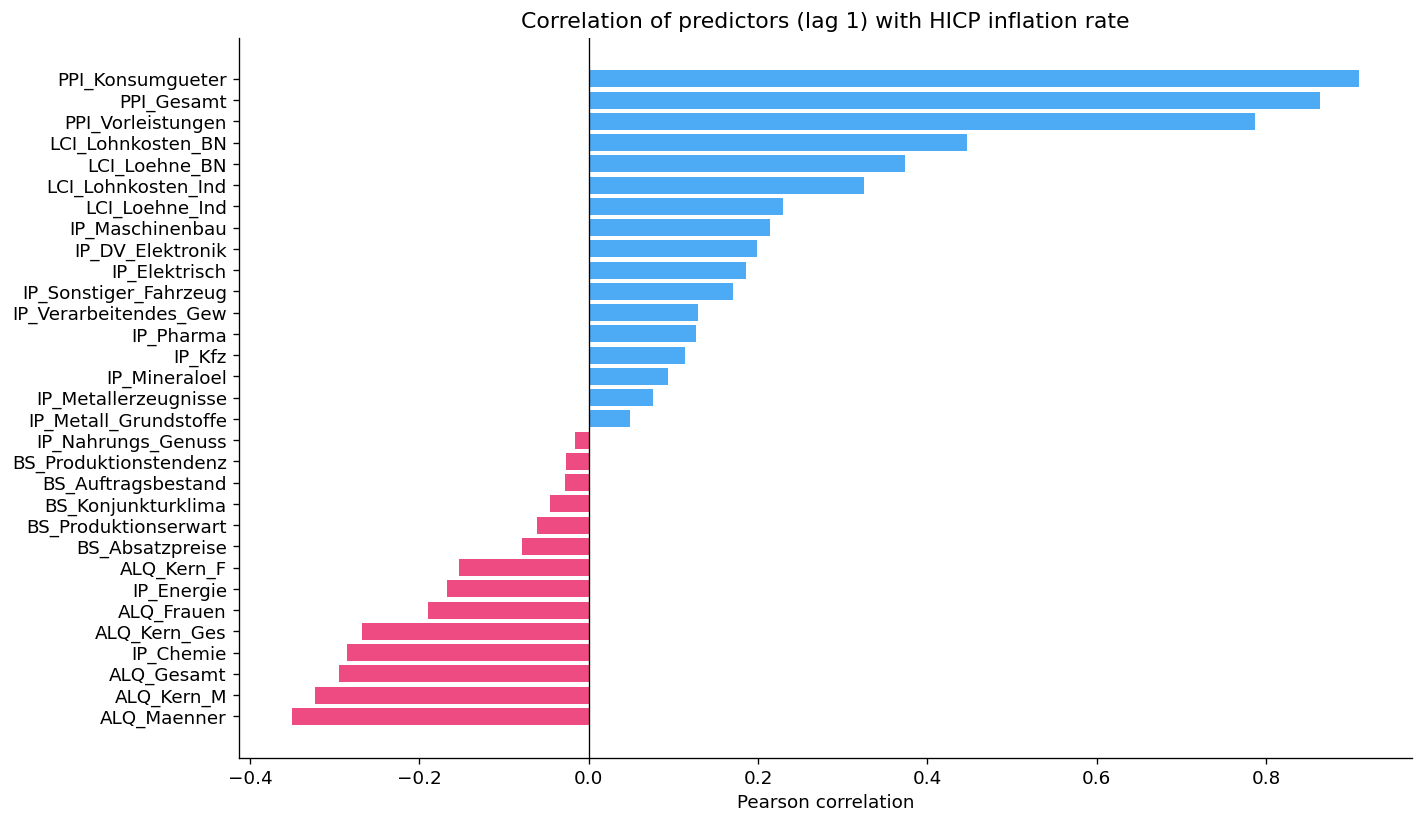

Figure saved: fig_02_korrelation.png


In [7]:
fig_02_correlation(X, y)

### 2b. Multicollinearity of the predictors

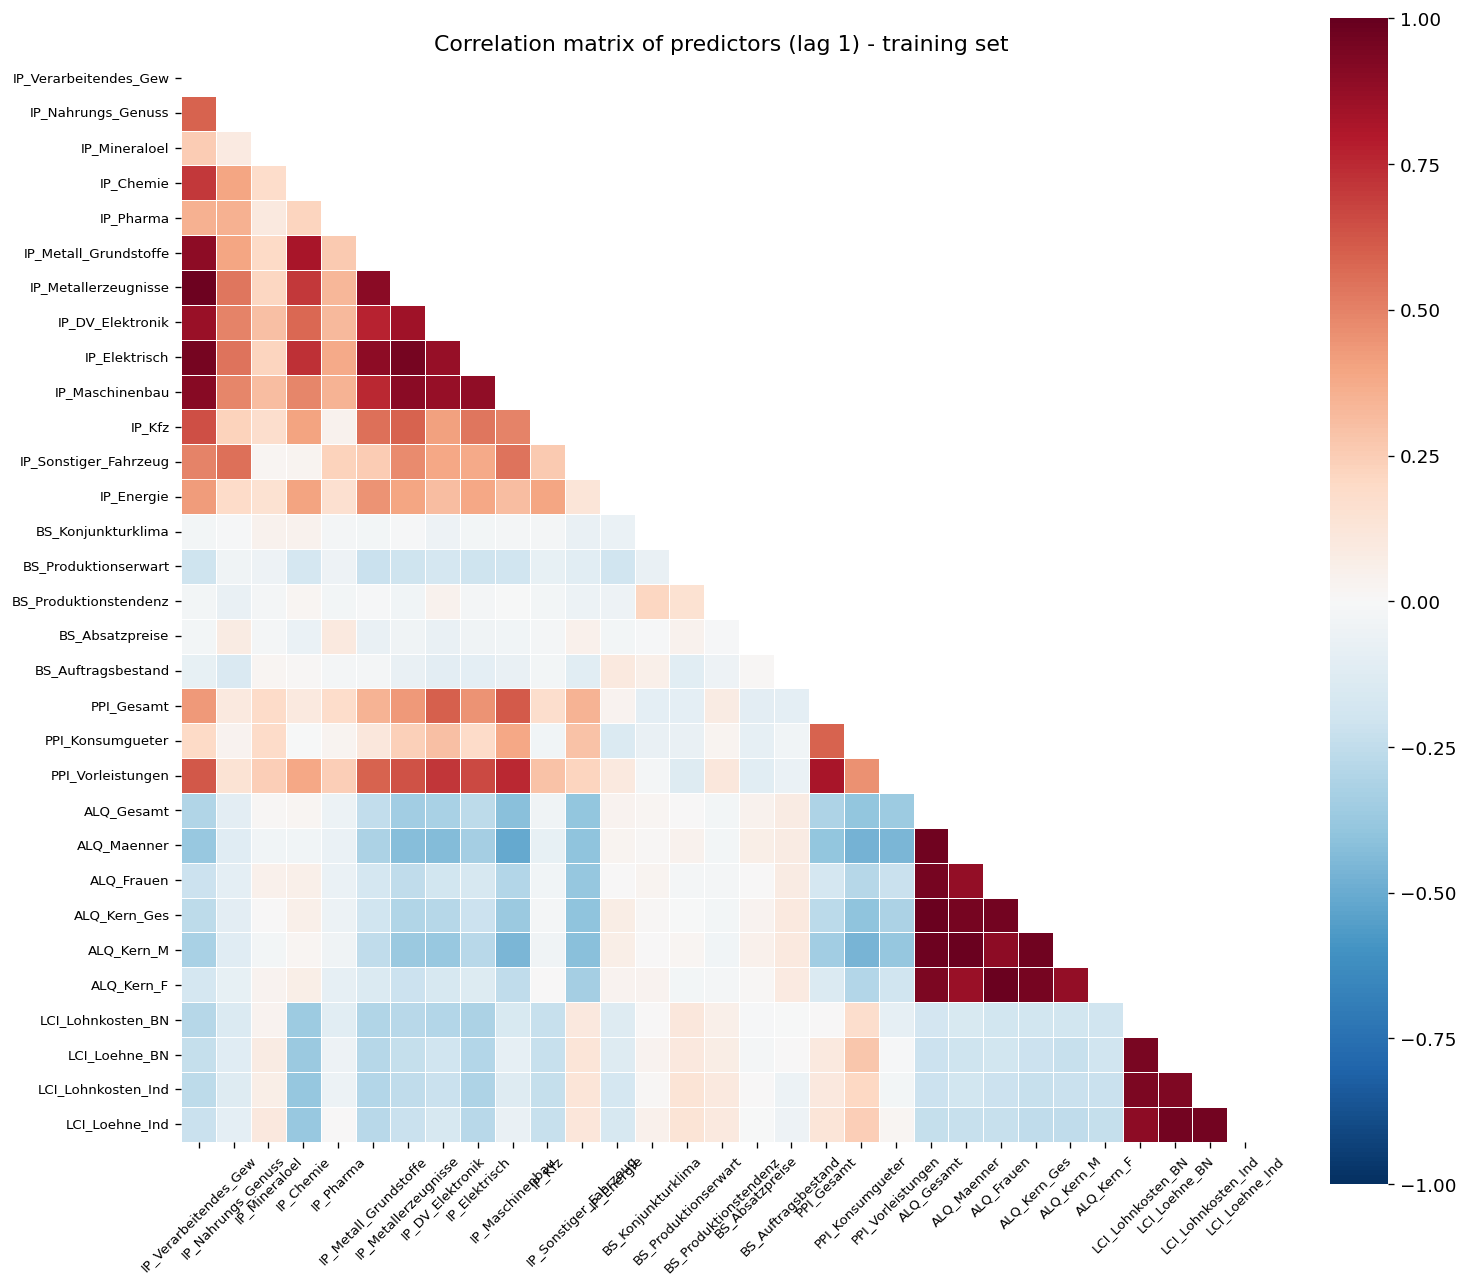

Figure saved: fig_02b_korr_heatmap.png

Condition number of X'X (standardised): 2.01e+05
-> Values >> 1 confirm strong multicollinearity and explain OLS instability.


In [8]:
fig_02b_heatmap(X, train_end)

### 2c. Stationarity tests (ADF/KPSS)

YoY year-on-year rates of change are the standard transformation for making integrated macroeconomic series stationary. The ADF and KPSS tests below confirm this empirically for HICP and for representative predictors from five sector groups.

**ADF** (H₀: unit root): rejection at *p* < 0.05 means stationary.  
**KPSS** (H₀: stationarity): non-rejection at *p* ≥ 0.05 means stationary.

**Finding:** Industrial production, PPI, business surveys, and unemployment are clearly stationary after the YoY transformation (ADF rejects, KPSS does not). HICP-YoY shows *high persistence* (ADF p ≈ 0.015, KPSS p ≈ 0.044, both close to the 5 % threshold), consistent with the well-known inertia of inflation series (Stock & Watson 2007). This is an empirical finding, not a procedural error: the YoY transformation clearly reduces the persistence of the HICP level (ADF p > 0.99) and follows the econometric standard.

In [9]:
stat_ctx = compute_stationarity_tests(df_raw, df_yoy)
export_stationarity_table(stat_ctx["df_stationarity"])


Stationarity tests (ADF & KPSS)
               Series Transform.  ADF-Stat.  ADF p-value ADF verdict  KPSS-Stat.  KPSS p-value KPSS verdict            Overall
                 HICP      Level      0.778       0.9913       I(1)?       2.443        0.0100        I(1)?     non-stationary
                 HICP    YoY (%)     -3.300       0.0149        I(0)       0.491        0.0437        I(1)? unclear/persistent
   IP (manufacturing)      Level     -2.366       0.1515       I(1)?       1.484        0.0100        I(1)?     non-stationary
   IP (manufacturing)    YoY (%)     -3.371       0.0120        I(0)       0.198        0.1000         I(0)         stationary
          PPI (total)      Level     -0.487       0.8945       I(1)?       2.051        0.0100        I(1)?     non-stationary
          PPI (total)    YoY (%)     -3.355       0.0126        I(0)       0.139        0.1000         I(0)         stationary
BS (business climate)      Level     -4.763       0.0001        I(0)       0.1

## 3. Model estimation: OLS, Ridge, LASSO

In [10]:
splits  = prepare_splits(X, y, train_end)

y_train    = splits["y_train"];  y_test    = splits["y_test"]
X_train    = splits["X_train"];  X_train_s = splits["X_train_s"]

print(f"Training data: {len(y_train)} months "
      f"({y_train.index[0].strftime('%Y-%m')} - {y_train.index[-1].strftime('%Y-%m')})")
print(f"Test data:     {len(y_test)} months "
      f"({y_test.index[0].strftime('%Y-%m')} - {y_test.index[-1].strftime('%Y-%m')})")
print(f"\nDimensions: {X_train.shape[0]} train x {X_train.shape[1]} features")
print(f"n < p: {'YES (high-dimensional)' if X_train.shape[0] < X_train.shape[1] else 'NO'}")

Training data: 225 months (2002-01 - 2021-05)
Test data:     36 months (2021-06 - 2024-10)

Dimensions: 225 train x 155 features
n < p: NO


In [11]:
print("Standardisation complete.")
print(f"Training means ~0: {abs(X_train_s.mean(axis=0)).max():.2e}")
print(f"Training std ~1:   {abs(X_train_s.std(axis=0) - 1).max():.2e}")

Standardisation complete.
Training means ~0: 3.16e-16
Training std ~1:   2.22e-16


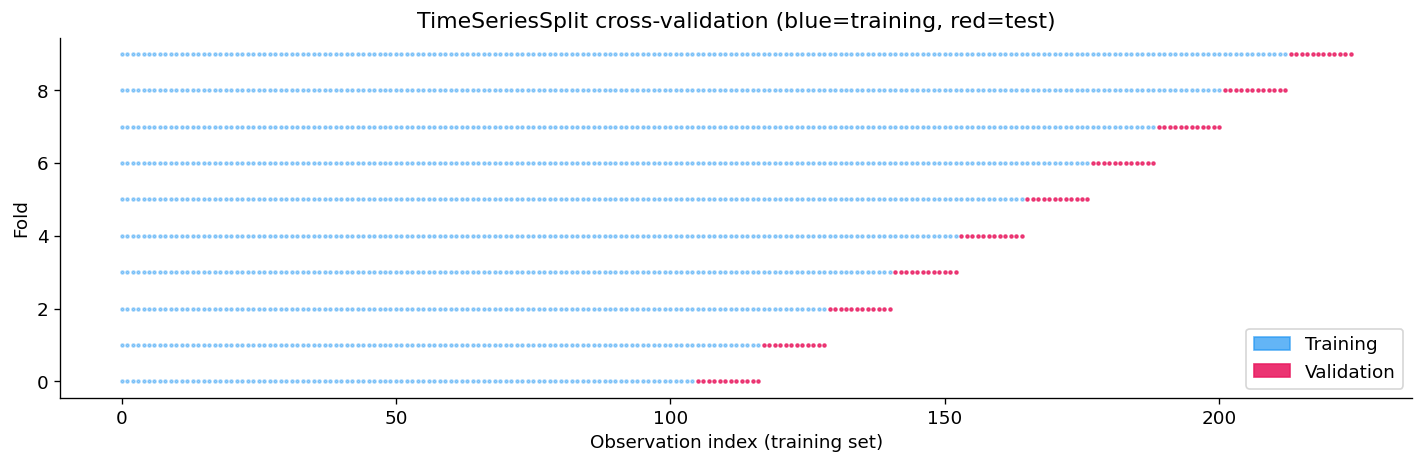

In [12]:
fig_03_tscv(splits["X_train_s"], config.TSCV)

## 3.5 Benchmarks: Random Walk and Lag Model (ADL)

The **lag model (ADL)** uses only HICP own lags {1, 2, 3, 6, 12} as predictors, which makes it a *restricted AR model* without exogenous regressors. The label "ADL" is used here as an umbrella term. Since no exogenous variables enter, it is effectively an autoregressive model with selected lags.

In [ ]:
# Fit all models (OLS, Ridge, LASSO, Elastic Net, Adaptive LASSO, AR/ADL, LASSO+HVPI)
models_ctx = fit_all_models(X, y, splits, tscv=config.TSCV)

# Convenience aliases
ols           = models_ctx["ols"]
ridge_cv      = models_ctx["ridge_cv"]
lasso_cv      = models_ctx["lasso_cv"]
enet_cv       = models_ctx["enet_cv"]
alasso        = models_ctx["alasso"]
ar_model      = models_ctx["ar_model"]
lasso_plus_cv = models_ctx["lasso_plus_cv"]
lambda_ridge  = models_ctx["lambda_ridge"]
lambda_lasso  = models_ctx["lambda_lasso"]
lambda_enet   = models_ctx["lambda_enet"]
l1_ratio_enet = models_ctx["l1_ratio_enet"]
results       = models_ctx["results"]
selected      = models_ctx["selected"]
top_idx       = models_ctx["top_idx"]

## 4. Comparison of results

The comparison of results is organised in **two levels**:

**Level 1 - Central (economically clean) comparison:**  
The lag model (ADL, HICP own lags only) against LASSO+HVPI (own lags + macro predictors).  
This comparison is *ceteris paribus* with respect to the own lags: both models know the last
inflation rate, and the only difference is the macro information content.  
-> Shows directly whether macro predictors contribute anything **beyond the persistence**.

**Level 2 - Illustrative part (regularisation vs. OLS overfitting):**  
OLS, Ridge, LASSO, Elastic Net, and Adaptive LASSO without HICP own lags.  
These models are **structurally disadvantaged**: they lack the by far strongest
single predictor, the last observed inflation rate. Their comparison against the Random Walk
is not a fair test of macro added value, but it does show that regularisation
effectively fixes the OLS overfitting at p/n ≈ 0.69.

The results table (`results_table.csv`) reflects this structure in the column **`Group`**
and in the row order: benchmark -> central comparison -> illustrative.

### Central comparison: AR/ADL vs. LASSO+HVPI (ceteris paribus)

The economically decisive question is:  
> *Does adding macro predictors to pure HICP persistence yield a
> forecasting gain?*

Both models use HICP own lags {1, 2, 3, 6, 12} as their basis:
- **Lag model (ADL):** HICP own lags only (persistence benchmark)
- **LASSO+HVPI:** HICP own lags **+ all macro predictors** (regularised)

The table below and `fig_05` put these models in the foreground.
The pure macro models (OLS to Adaptive LASSO) are marked as the *illustrative part*.

In [14]:
print("=" * 75)
print("Results overview: benchmarks vs. regularisation models")
print("=" * 75)
print(results.to_string())
print("=" * 75)

# Build the combined context (used by the reporting functions)
inf_ctx = compute_single_split_inference(models_ctx, splits)

ctx = {
    "df_raw": df_raw, "df_yoy": df_yoy,
    "X": X, "y": y, "train_end": train_end,
    **splits, **models_ctx, **inf_ctx, **stat_ctx,
}

Results overview: benchmarks vs. regularisation models
                         Group        λ Train MSE  Test MSE  Test RMSE  RMSE/RW  Test R² Non-zero coeff.
Model                                                                                                   
Random Walk          Benchmark        -         -    0.8833     0.9398   1.0000   0.8933               -
Lag model (ADL)      Benchmark        -         -    1.1114     1.0542   1.1217   0.8657               5
LASSO+HVPI       With own lags  0.06368         -    2.1741     1.4745   1.5689   0.7374         7 / 160
OLS               Illustrative        -    0.0242   11.5850     3.4037   3.6216  -0.3994             155
Ridge             Illustrative   54.789    0.1044    3.8303     1.9571   2.0824   0.5373             155
LASSO             Illustrative  0.02967    0.1383    3.3534     1.8312   1.9485   0.5949              29
Elastic Net       Illustrative  0.03917    0.1362    3.4056     1.8454   1.9636   0.5886              34


  Adaptive LASSO        1.3769       [0.994, 1.770]   DM    -1.983    0.0553      *
-------------------------------------------------------------------------------------
Stat. > 0: model beats RW  | * p<0.10  ** p<0.05
CW p-value one-sided (H1: nested model more accurate), DM two-sided.
Note: T=36 test points - low test power, differences usually n.s.
Bonferroni: 7 tests vs. RW (single split), p_adj = min(7*p, 1).


### 4.1 Inference on the single split (block bootstrap + DM/CW test)

**Research question:** Is the ranking of the main table statistically robust on T=36 test points?

Three complementary methods:
- **Block-bootstrap 95% CI** (circular, $l=6\approx\sqrt{T}$, $B=2000$): quantifies the
  sampling variability of the RMSE under serially correlated errors.
- **Diebold-Mariano test** (HLN-corrected, $h=1$, two-sided): for the
  **non-nested** comparisons (pure macro models: OLS, Ridge, LASSO,
  Elastic Net, Adaptive LASSO vs. RW).
- **Clark-West test** (Clark & West 2007, one-sided, $H_1$: model beats RW):
  for the **nested** comparisons. The lag model (ADL) and LASSO+HVPI contain
  HVPI\_L1, the RW predictor, and are therefore nested in the RW.
  Under $H_0$ the DM test is downward-biased for nested models, because the
  larger model estimates extra parameters and its MSPE is thereby upward-biased.
  CW corrects for this via the term $(\hat{y}_{RW} - \hat{y}_M)^2$:
  $f_t = e_{RW}^2 - [e_M^2 - (\hat{y}_{RW}-\hat{y}_M)^2]$.

**Multiplicity:** Since 7 models are tested against the Random Walk at the same time
(single split: 5 × DM + 2 × CW, rolling-origin analogously), the $p$-values are adjusted
using a **Bonferroni correction** ($p_{\mathrm{adj},i} = \min(n \cdot p_i,\, 1)$,
$n = 7$ tests). For the null finding here, where all tests are already not
significant at the 5 % level after correction, the adjustment does not change the
conclusion, but it is formally required (see table column *Sig. adj.*).

**Expected result:** At $T=36$ the test power is low. Differences on the
order of RMSE/RW $\approx 1.4$ vs. $1.0$ are usually not significant.
The block-bootstrap CIs indicate the range within which the true RMSE lies with 95%
probability.

In [15]:
export_inference_table(inf_ctx["df_inference"], splits["y_test"])

results/inference_table.csv saved.
results/inference_table.tex saved.
                 Test RMSE  CI 2.5%  CI 97.5% Test  Stat.  p-value  Sig.  p adj. (Bonf.) Sig. adj.
Model                                                                                             
Random Walk         0.9398   0.7456    1.0979    -    NaN      NaN     -             NaN         -
Lag model (ADL)     1.0542   0.7640    1.3175   CW  1.350   0.0885     *          0.6195      n.s.
OLS                 3.4037   2.1921    4.3771   DM -3.407   0.0017    **          0.0119        **
Ridge               1.9571   1.4620    2.3857   DM -4.167   0.0002    **          0.0014        **
LASSO               1.8312   1.5052    2.1640   DM -4.761   0.0000    **          0.0000        **
Elastic Net         1.8454   1.5116    2.1639   DM -4.816   0.0000    **          0.0000        **
LASSO+HVPI          1.4745   0.8907    1.9221   CW  0.466   0.3205  n.s.          1.0000      n.s.
Adaptive LASSO      1.3769   0.9936    

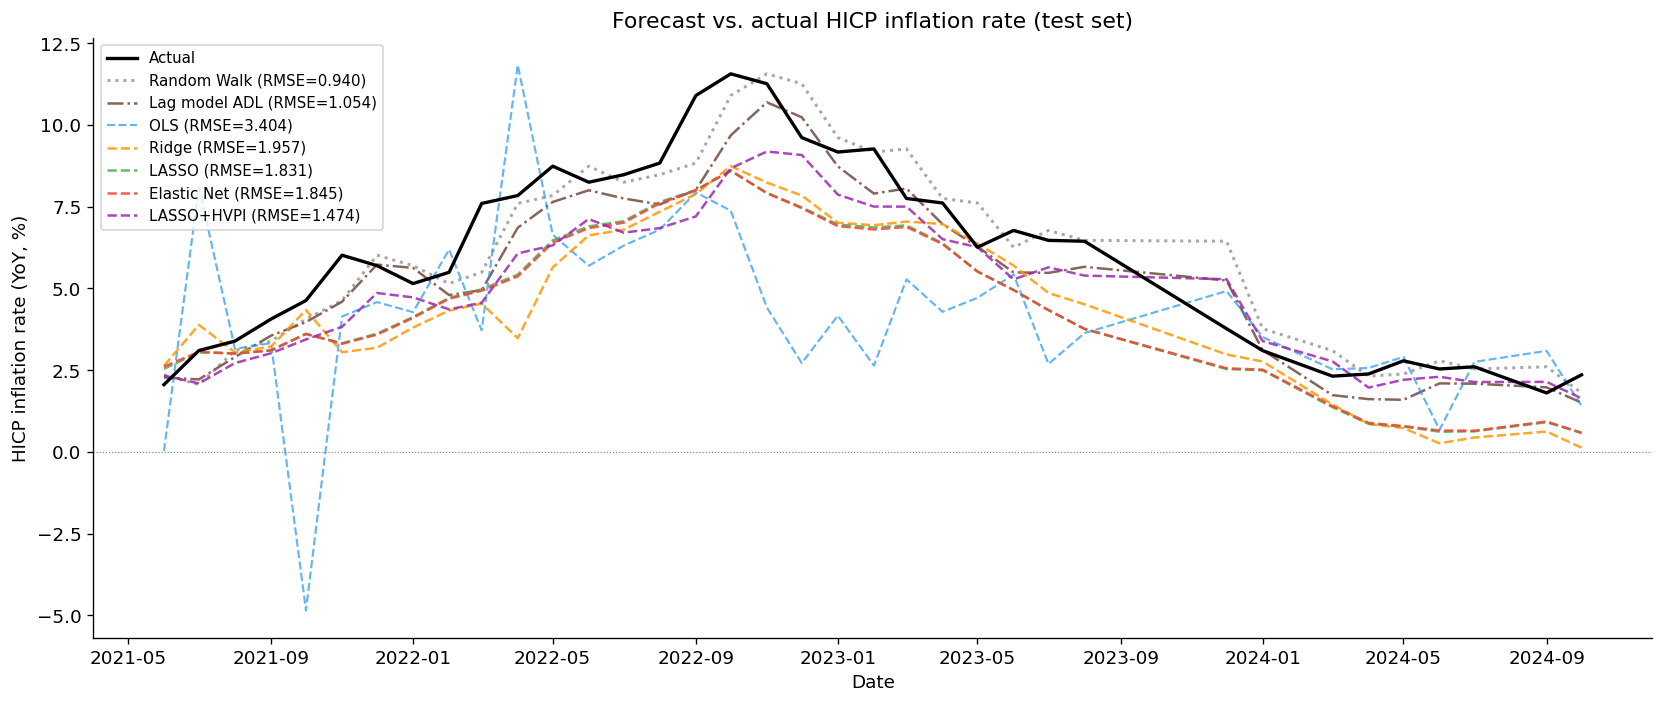

Figure saved: fig_04_prognose.png


In [16]:
fig_04_forecast(ctx)

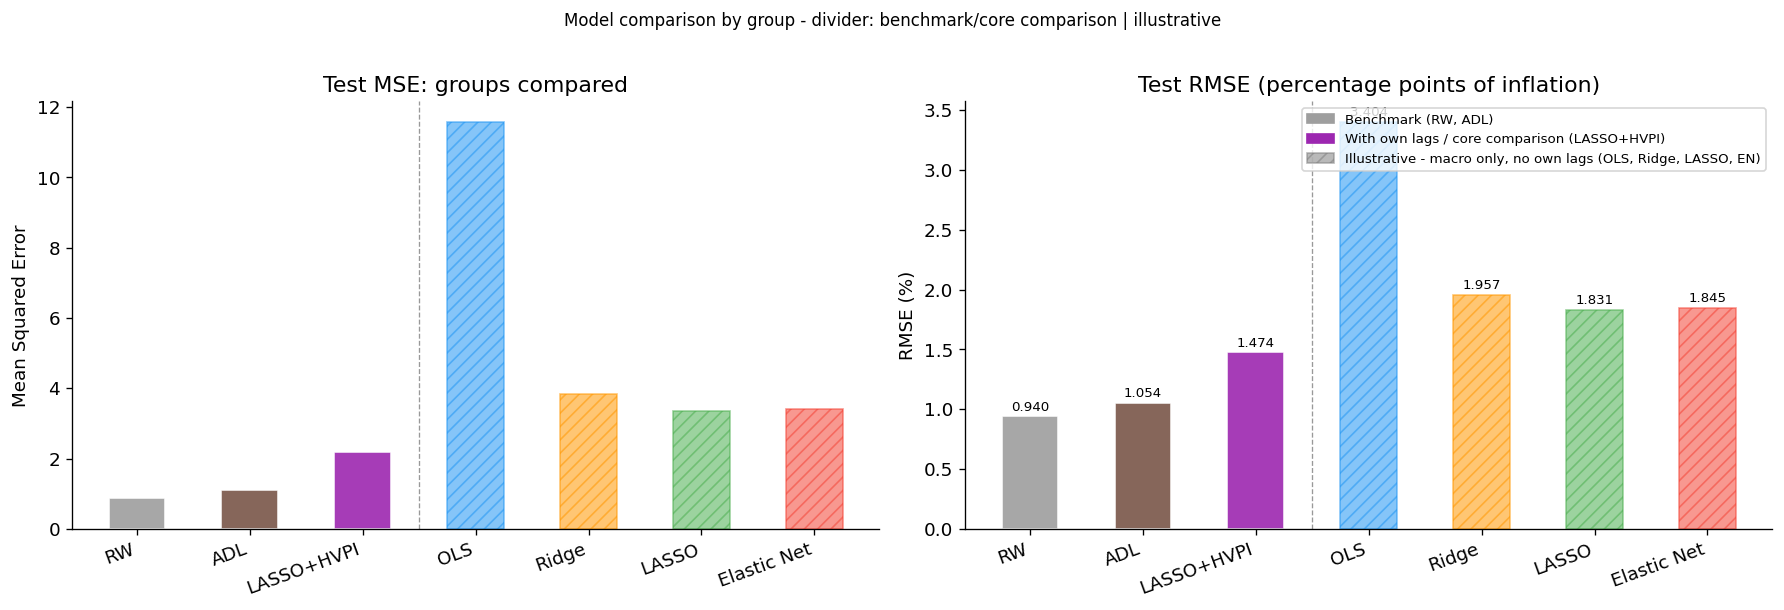

Figure saved: fig_05_mse_vergleich.png


In [17]:
fig_05_mse_comparison(ctx)

## 4.5 Rolling-Origin Out-of-Sample

In [18]:
oos_ctx = compute_oos_predictions(models_ctx, splits, X, y, train_end)
ctx.update(oos_ctx)

AR:   0%|          | 0/36 [00:00<?, ?it/s]

OLS:   0%|          | 0/36 [00:00<?, ?it/s]

Ridge:   0%|          | 0/36 [00:00<?, ?it/s]

LASSO:   0%|          | 0/36 [00:00<?, ?it/s]

Elastic Net:   0%|          | 0/36 [00:00<?, ?it/s]

LASSO+HVPI:   0%|          | 0/36 [00:00<?, ?it/s]

Rolling-origin forecasts computed (all models incl. Elastic Net).
Rolling-origin RMSE (expanding window, h=1, λ fixed from initial CV):
-----------------------------------------------------------------
  RW            : RMSE = 0.9398   RMSE/RW = 1.000 (Ref)
  AR            : RMSE = 0.9499   RMSE/RW = 1.011
  OLS           : RMSE = 2.3430   RMSE/RW = 2.493
  Ridge         : RMSE = 1.1592   RMSE/RW = 1.233
  LASSO         : RMSE = 1.0865   RMSE/RW = 1.156
  Elastic Net   : RMSE = 1.0903   RMSE/RW = 1.160
  LASSO+HVPI    : RMSE = 0.9500   RMSE/RW = 1.011


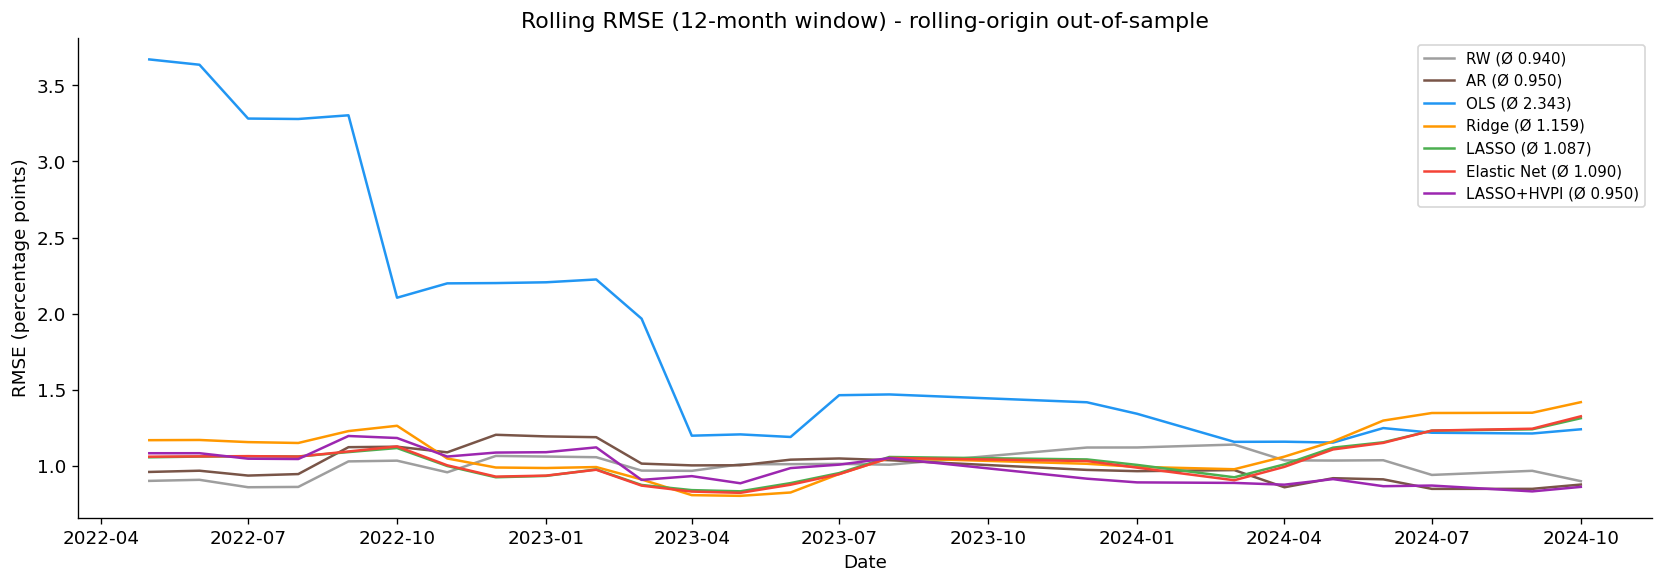

Figure saved: fig_11_rolling_rmse.png


In [19]:
fig_11_rolling_rmse(oos_ctx["oos_df"], oos_ctx["y_oos_ref"], oos_ctx["oos_rmse"])

In [20]:
RUN_ADAPTIVE_RO = True  # optional robustness run (~10-20 min, lambda per origin), default: off

if RUN_ADAPTIVE_RO:
    adap_ctx    = compute_adaptive_oos(X, y, splits, train_end, config.TSCV_INNER)
    compare_ctx = compute_compare_oos(oos_ctx, adap_ctx, oos_ctx["y_oos_ref"])
else:
    adap_ctx    = None
    compare_ctx = {"compare_oos": oos_ctx["oos_df"], "adap_rmse": oos_ctx["oos_rmse"]}
ctx.update({**(adap_ctx or {}), **compare_ctx})

Starting adaptive rolling-origin (λ per origin via CV) ...
(Runtime ~10-20 min - progress via tqdm per model)


LASSO (adapt.):   0%|          | 0/36 [00:00<?, ?it/s]

Ridge (adapt.):   0%|          | 0/36 [00:00<?, ?it/s]

Elastic Net (adapt.):   0%|          | 0/36 [00:00<?, ?it/s]

LASSO+HVPI (adapt.):   0%|          | 0/36 [00:00<?, ?it/s]

Adaptive LASSO (adapt.):   0%|          | 0/36 [00:00<?, ?it/s]

Done.

Rolling-origin RMSE: fixed λ vs. adaptive λ per origin
Model                        RMSE   RMSE/RW
---------------------------------------------
  RW                       0.9398    1.0000
  AR                       0.9499    1.0107
  LASSO                    1.0865    1.1561
  LASSO (adapt.)           1.2421    1.3217 <- adapt.
  Ridge                    1.1592    1.2334
  Ridge (adapt.)           1.4230    1.5141 <- adapt.
  Elastic Net              1.0903    1.1601
  Elastic Net (adapt.)     1.2332    1.3122 <- adapt.
  LASSO+HVPI               0.9500    1.0109
  LASSO+HVPI (adapt.)      1.0027    1.0669 <- adapt.
  Adaptive LASSO (adapt.)  0.9937    1.0574 <- adapt.

Comparison table saved: results/compare_oos_table.csv


### 4.5.1 Single window vs. rolling origin: methodological interpretation

The results in Section 4 (fixed single split) and Section 4.5 (rolling origin) differ
considerably for some models. This is not a contradiction but informative:

| Model | Single-window RMSE | Rolling-origin RMSE | Difference |
|--------|-------------------:|--------------------:|----------:|
| Random Walk | 0.94 | 0.94 | ≈ 0 |
| AR (ADL) | 1.05 | 0.95 | -0.10 |
| LASSO+HVPI | 1.47 | 0.95 | -0.52 |
| LASSO | 1.83 | 1.09 | -0.74 |
| Elastic Net | 1.85 | 1.09 | -0.76 |
| Ridge | 1.96 | 1.16 | -0.80 |
| OLS | 3.40 | 2.34 | -1.06 |

**Mechanistic explanation of the discrepancy:**

*Single window (fixed split 2021-06 to 2024-10):* λ and all model weights are estimated
**once** on the pre-pandemic dataset (up to 2021-05) and then applied rigidly to
the test window. The test window happens to cover the exceptional
energy-price and inflation shock of 2021-2022, a regime that did not appear in training.
Models with many parameters (Ridge, LASSO with macro features) fail here especially badly,
because the coefficients estimated once systematically miss this shock.

*Rolling origin (expanding window):* The model is **re-estimated every month**.
As soon as the shock months enter the training window, the weights adapt.
AR and LASSO+HVPI benefit the most, because the HICP own lags adapt quickly to the
inflation impulse.

**Consequence for presenting the results:** The rolling-origin design is methodologically
more robust and is reported as the **main result**. The fixed single split serves as an
illustration of regime dependence: it shows how vulnerable pure macro models without
inflation-persistence information are to unexpected regime shifts.

> *Both designs confirm the key finding:* no macro model without HICP own lags
> beats the Random Walk. Only LASSO+HVPI and AR match it (rolling) narrowly.
> The significance of this gap is tested by the Diebold-Mariano test in the next section.


In [21]:
dm_ctx = compute_dm_tests(oos_ctx, adap_ctx=adap_ctx)
ctx.update(dm_ctx)

Inference tests vs. Random Walk (h=1, T≈36)
  DM: Diebold-Mariano, HLN-adjusted, two-sided (non-nested models)
  CW: Clark-West (2007), one-sided H1: model better (nested models)
Model                  Test     Stat.   p-value   Sig.
---------------------------------------------------------
  AR                     CW    +1.489    0.0683      *
  LASSO+HVPI             CW    +1.720    0.0427     **
  LASSO                  DM    -0.955    0.3463   n.s.
  Elastic Net            DM    -0.975    0.3361   n.s.
  Ridge                  DM    -1.454    0.1548   n.s.
  OLS                    DM    -1.870    0.0698      *
  Adaptive LASSO         DM    -0.342    0.7347   n.s.
---------------------------------------------------------
Stat. > 0: model beats RW  | * p<0.10  ** p<0.05
CW p-value one-sided, DM p-value two-sided.
Multiple testing: 7 tests vs. RW (rolling-origin, h=1).
Bonferroni: p_adj = min(7*p, 1). Under the null finding the conclusion is unchanged.


### 4.5.2 Regime analysis: shock vs. disinflation (AP25)

The 36-month test window (2021-06 to 2024-10) covers two structurally different regimes:

- **Shock regime** (2021-06 to 2023-03, n=22): energy-price shock, HICP-YoY rises to as high as 11.6 % (Oct. 2022). In a near-I(1) series during accelerating inflation, the Random Walk is mechanically hard to beat.
- **Disinflation phase** (2023-04 to 2024-10, n=14): inflation falls back towards 2 %, monetary transmission is delayed, and expectations remain well anchored.

**Purpose:** To check whether "macro does not beat RW" is only a statement about the shock regime or also holds during disinflation, and thereby to strengthen the external validity of the key claim.


In [22]:
reg_ctx = compute_regime_analysis(oos_ctx)
ctx.update(reg_ctx)
export_regime_table(
    reg_ctx["df_regime"],
    shock_end=reg_ctx["shock_end"],
    n_shock=reg_ctx["n_shock"],
    n_disfl=reg_ctx["n_disfl"],
)


Regime analysis (rolling-origin, h=1)
  Shock        (2021-06 - 2023-03): n=22
  Disinflation (2023-04 - 2024-10): n=14

Model                RMSE_S   R/RW_S   RMSE_D   R/RW_D   RMSE_G   R/RW_G
-------------------------------------------------------------------------
  RW                 0.9584   1.0000   0.9098   1.0000   0.9398   1.0000
  AR                 1.0173   1.0615   0.8329   0.9155   0.9499   1.0107
  OLS                2.8481   2.9716   1.1699   1.2858   2.3430   2.4930
  Ridge              1.0304   1.0751   1.3368   1.4693   1.1592   1.2334
  LASSO              0.9927   1.0358   1.2194   1.3403   1.0865   1.1561
  Elastic Net        0.9919   1.0349   1.2292   1.3511   1.0903   1.1601
  LASSO+HVPI         1.0134   1.0573   0.8410   0.9243   0.9500   1.0109
-------------------------------------------------------------------------
RW RMSE: Shock=0.9584  Disinfl.=0.9098  Total=0.9398
n:       Shock=22  Disinfl.=14  Total=36

FINDING Shock:       Best non-RW model = Elastic Ne

### 4.5.2b Random Forest: a nonlinear benchmark in the shock regime (out of interest)

Not part of the paper - a quick check of the *model-class* caveat from Section 6:
Medeiros et al. (2021) find their ML advantage mainly through **random forests**
that capture nonlinearities and interactions. Does a random forest beat the Random
Walk here, especially in the energy-price **shock** regime (2021-06 to 2023-03)?

Quick & dirty: the existing `rolling_origin` helper is reused (expanding window, h=1,
per-origin refit). Two feature sets are compared: RF on the LASSO+HVPI matrix
(own lags + macro, the fair analog to LASSO+HVPI/AR) and RF on the pure macro
matrix (analog to Ridge/LASSO/EN). Hyperparameters are fixed (300 trees, defaults) -
no tuning, since the goal is a directional check, not an optimised competitor.

In [ ]:
# --- Random Forest (nonlinear benchmark) - out of interest, not part of the paper ---
from sklearn.ensemble import RandomForestRegressor
from src.evaluation import rolling_origin
from src.config import REGIME_SHOCK_END

_rf = lambda: RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

# RF on own lags + macro (fair analog to LASSO+HVPI/AR)
oos_rf = rolling_origin(
    _rf, splits["X_plus"], splits["y_plus"], splits["start_plus"], desc="RF (lags+macro)",
).rename("RF (lags+macro)")

# RF on pure macro predictors (analog to Ridge/LASSO/EN)
oos_rf_macro = rolling_origin(
    _rf, X, y, train_end, desc="RF (macro only)",
).rename("RF (macro only)")

# Regime split - identical shock_end as Section 4.5.2
y_ref     = oos_ctx["y_oos_ref"]
shock_end = pd.Timestamp(REGIME_SHOCK_END)
common    = oos_rf.index.intersection(y_ref.index)
idx_s     = common[common <= shock_end]
idx_d     = common[common >  shock_end]

def _rmse(series, idx):
    p = series.reindex(idx).dropna()
    a = y_ref.loc[p.index]
    return float(np.sqrt(np.mean((p - a) ** 2))) if len(p) else np.nan

_refs = [
    ("RW",            oos_ctx["oos_df"]["RW"]),
    ("AR",            oos_ctx["oos_ar"]),
    ("LASSO+HVPI",    oos_ctx["oos_lasso_plus"]),
    ("RF (lags+macro)", oos_rf),
    ("RF (macro only)", oos_rf_macro),
]
df_rf = pd.DataFrame([
    {"Model": n,
     "RMSE Shock":    _rmse(s, idx_s),
     "RMSE Disinfl.": _rmse(s, idx_d),
     "RMSE Total":    _rmse(s, common)}
    for n, s in _refs
]).set_index("Model")

rw_s, rw_d, rw_g = df_rf.loc["RW"]
df_rf["RMSE/RW Shock"]    = (df_rf["RMSE Shock"]    / rw_s).round(3)
df_rf["RMSE/RW Disinfl."] = (df_rf["RMSE Disinfl."] / rw_d).round(3)
df_rf["RMSE/RW Total"]    = (df_rf["RMSE Total"]    / rw_g).round(3)

print(f"Random Forest vs. benchmarks (rolling-origin, h=1; shock end = {REGIME_SHOCK_END})")
print(f"n: shock={len(idx_s)}, disinflation={len(idx_d)}, total={len(common)}")
print("=" * 78)
print(df_rf.round(4).to_string())
print("=" * 78)
_best = df_rf.drop("RW")["RMSE/RW Shock"].idxmin()
print(f"Best non-RW model in the shock: {_best} "
      f"(RMSE/RW = {df_rf.loc[_best, 'RMSE/RW Shock']:.3f})")

**Finding on the random forest (current run):**

The random forest does **not** beat the Random Walk in any regime - and it is *worst*
exactly in the shock (RMSE/RW ≈ 1.5 with lags+macro, ≈ 1.7 macro-only vs. 1.0 for the RW).
Two reasons: (i) with n ≈ 120 training months a 300-tree forest badly overfits the
p ≈ 20 predictors, and (ii) tree ensembles cannot **extrapolate** - during the
energy-price shock inflation climbs to new highs the model has never seen in training,
so its forecasts stay stuck below the realised path. This does not contradict Medeiros
et al. (2021): their RF advantage rests on much larger samples (hundreds of monthly US
observations) and calmer, broader out-of-sample windows. Here the model-class extension
*reinforces* the core result rather than overturning it: **neither shrinkage nor a
nonlinear forest adds value over inflation persistence in this small-sample shock
regime.**

### 4.5.3 Time-varying predictive ability: Giacomini-Rossi fluctuation test (AP26)

**Extended reframing of the research question**

The previous tests (DM, CW) answer: *"Does macro beat the RW over the full window?"* - answer: **no** (all tests n.s., Phases A-D).

A scientifically complete analysis additionally asks:  
**"Is relative forecast accuracy stable over time, or does the macro added value vary over the business cycle?"**

The **Giacomini-Rossi fluctuation test (2010)** tests *conditional predictive ability* (Giacomini & White 2006) rather than *unconditional predictive ability* as DM/CW do: H₀ = constant relative predictive ability vs. H₁ = time-varying predictive ability. The rolling DM statistic over a window m ≈ ⌊T/3⌋ shows *when* a model outperforms or falls short of the RW.

**GR_t(m) = √m · d̄_{t,m} / ĥ_{t,m}**  
with d_t = e²_RW - e²_model (loss difference), ĥ = Newey-West long-run variance.  
Critical values: Giacomini & Rossi (2010), Tab. 1 (depending on μ = m/T).

**Sources:** Giacomini & Rossi (2010), *Forecast Comparisons in Unstable Environments*, JAE 25, 595-620. Giacomini & White (2006), *Tests of Conditional Predictive Ability*, Econometrica 74, 1545-1578.


In [23]:
gr_ctx = compute_giacomini_rossi(oos_ctx, adap_ctx=adap_ctx)
ctx.update(gr_ctx)


Giacomini-Rossi fluctuation test (Giacomini & Rossi 2010, JAE 25)
  Conceptual framework: conditional predictive ability (Giacomini & White 2006)
  Reframing: H0 = constant predictive ability vs. H1 = time-varying predictive ability
  T=36 OOS obs., m=12 (μ=0.333), Newey-West bw=1
  Critical values (Tab. 1, GR 2010): cv_10%=1.683, cv_5%=1.913
  GR_t(m) = √m · d̄_t / ĥ_t,  d_t = e²_RW - e²_model

  Model                 sup|GR|    > cv_5%?   > cv_10%?
  ---------------------------------------------------------
  AR                      2.025      YES **       YES *
  LASSO+HVPI              2.546      YES **       YES *
  LASSO                   1.409          no          no
  Ridge                   1.773          no       YES *
  Adaptive LASSO          1.268          no          no
  ---------------------------------------------------------
  Band exceedance: sup|GR| > cv_5%=1.913 (**) or cv_10%=1.683 (*).
  Never/rarely significant -> H0 (constant predictive ability) not rejected.


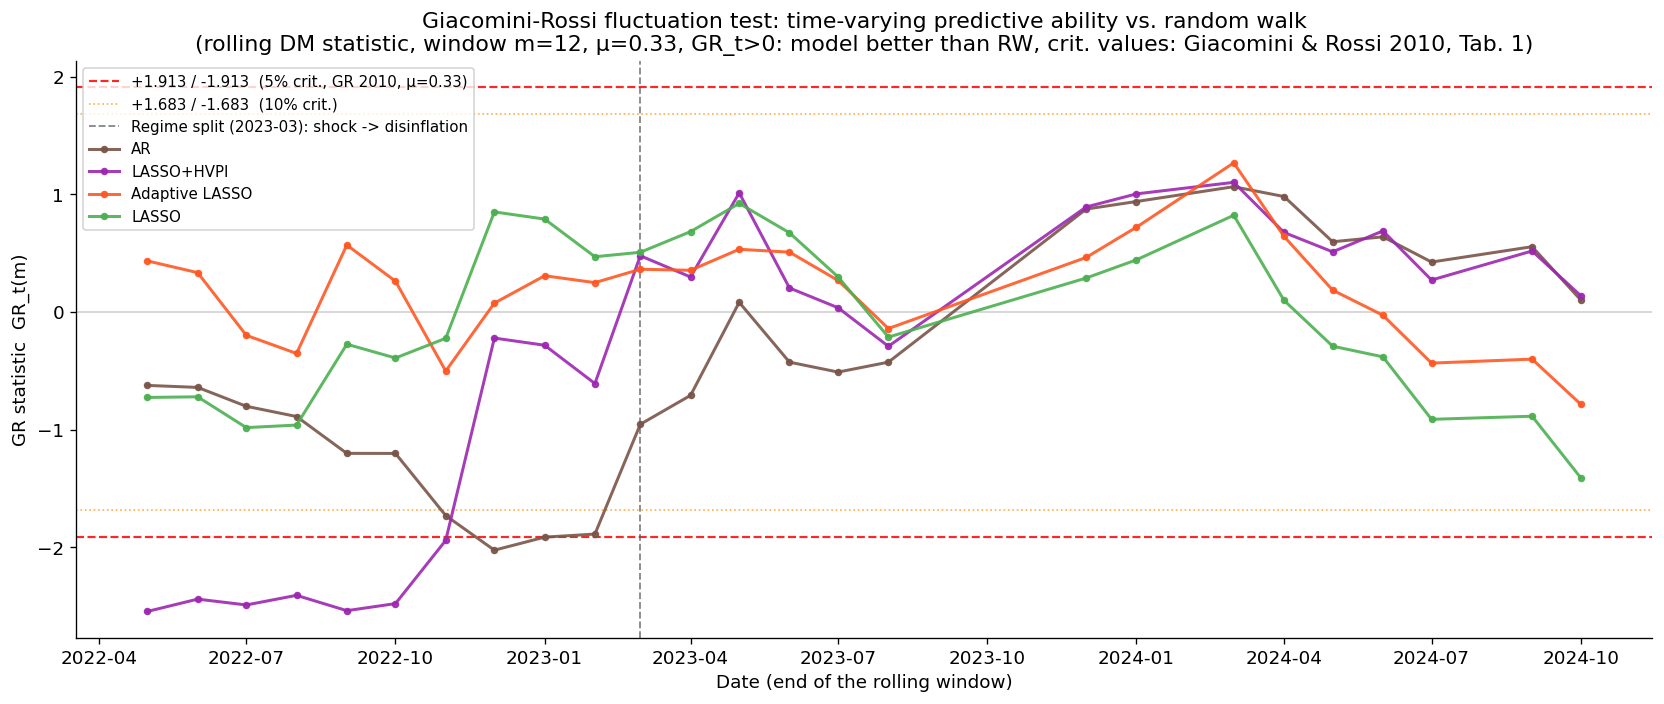

Figure saved: fig_14_giacomini_rossi.png
results/gr_table.csv saved. (25 time points, m=12, μ=0.333)
  cv_5%=1.913, cv_10%=1.683 (Giacomini & Rossi 2010, Tab. 1)


In [24]:
fig_14_giacomini_rossi(gr_ctx)
export_gr_table(gr_ctx)

### 4.5.4 Sample extension: a genuine post-shock out-of-sample test (AP32)

**Fixes G6 (truncation) and hardens G27 (single-regime problem).**

The main test window ends at **2024-10**, not because of the target variable (HICP is valid up to 2025-12), but because **a single predictor series** (`BS_Produktionserwart`, the business survey "production expectations") already ends in 2024-09 and, through the row-wise `dropna()`, truncates the *entire* feature matrix. The out-of-sample window is therefore structurally dominated by the 2021-2024 energy-price shock, exactly the regime in which the near-I(1) Random Walk is mechanically almost impossible to beat. The claim "RW unbeatable" was thus never tested *outside* the shock out-of-sample.

**Research question:** Is the null finding an artefact of the truncated, shock-dominated test window?

**Approach:** Drop the binding series, so the out-of-sample window extends to **2025-12 (+14 months)** and the post-shock segment grows from 14 to **28 months**. The training window stays identical to the main run (the first out-of-sample point remains 2021-06), so the shock segment stays directly comparable. Per regime (shock ≤ 2023-03 / post-shock) the models are tested against the RW: **Clark-West** for the nested models (AR, LASSO+HVPI ⊃ RW), **Diebold-Mariano** for the pure macro models.

**Finding:** In the calmer post-shock regime (n=28), **AR** (RMSE/RW ≈ 0.95, CW p ≈ 0.03) and **LASSO+HVPI** (≈ 0.95, CW p ≈ 0.04) beat the Random Walk. The null finding of the main run was window-driven. The key claim *macro added value ≈ 0* nonetheless holds: AR (without macro) ≈ LASSO+HVPI (with macro). What beats the RW is inflation persistence, not the macro variables. The pure macro models (Ridge/LASSO/EN) remain worse than the RW here too.

**Honest caveat:** n=28 remains moderate. With a Bonferroni correction over the two nested tests (2·p), the significance holds only at the 10 % level. The more precise takeaway is therefore: *the Random Walk is unbeatable only in the inflation-shock regime. In calm phases a simple AR already beats it, but macro predictors add nothing beyond the persistence in any regime.*

In [25]:
# Section 4.5.4 - Sample extension (AP32): drop the binding series (BS_Produktionserwart),
# extend the out-of-sample window to 2025-12, and test the post-shock regime genuinely out-of-sample for the first time.
from src.evaluation import compute_robustness_extended_oos
from src.reporting import export_robustness_extended_table

ext_ctx = compute_robustness_extended_oos(df_yoy)
ctx["robustness_extended"] = ext_ctx          # namespaced -> picked up by update_readmes (Section 8)
export_robustness_extended_table(ext_ctx)


Robustness check: sample extension (AP32 / G6)
Removed (binding) series: BS_Produktionserwart
Target series until: 2024-10 (before)  ->  2025-12 (after)  [+14 months]
Features:        150 (after drop)
OOS window:      2021-06 - 2025-12 (n=50, was 36)


AR (ext):   0%|          | 0/50 [00:00<?, ?it/s]

OLS (ext):   0%|          | 0/50 [00:00<?, ?it/s]

Ridge (ext):   0%|          | 0/50 [00:00<?, ?it/s]

LASSO (ext):   0%|          | 0/50 [00:00<?, ?it/s]

EN (ext):   0%|          | 0/50 [00:00<?, ?it/s]

LASSO+HVPI (ext):   0%|          | 0/50 [00:00<?, ?it/s]


Regime split (shock ≤ 2023-03 < post-shock):  n_shock=22, n_post=28
Model            RMSE_S   R/RW_S   RMSE_P   R/RW_P   R/RW_G       Post-test
------------------------------------------------------------------------------
  RW             0.9584   1.0000   0.6683   1.0000   1.0000         - (Ref)
  AR             1.0173   1.0615   0.6374   0.9538   1.0217   CW +1.85   **
  OLS            3.0430   3.1750   0.9847   1.4735   2.6566   DM -1.13 n.s.
  Ridge          0.9998   1.0431   1.0574   1.5823   1.2764   DM -2.01    *
  LASSO          0.9826   1.0252   0.9927   1.4855   1.2218   DM -1.68 n.s.
  Elastic Net    0.9817   1.0243   1.0103   1.5119   1.2336   DM -1.76    *
  LASSO+HVPI     1.0134   1.0573   0.6365   0.9524   1.0185   CW +1.70   **
------------------------------------------------------------------------------
RW RMSE: Shock=0.9584  Post=0.6683  Total=0.8089
Post-test: DM (HLN, two-sided) / CW (2007, one-sided, nested) vs. RW, Stat>0 -> model better.
Bonferroni (post segme

### 4.5.5 Target-variable robustness: MoM specification and Atkeson-Ohanian benchmark (AP29)

**Fixes G31 (the benchmark choice predetermines the result).**

The YoY rate is near I(1) and thus an exceptionally strong, persistence-loaded benchmark. "RW unbeatable" could partly be an artefact of the target definition. This robustness check tests that with an alternative specification:

- **Target variable MoM** (Δ % month-over-month instead of the annual rate), which has clearly lower persistence and a weaker RW benchmark.
- **Atkeson-Ohanian benchmark (2001):** a rolling 12-month average of the MoM rates as the forecast, the classic, hard-to-beat benchmark of the inflation-forecasting literature.

**Research question:** Does the macro added value stay ≈ 0 under MoM as well, or is the null finding specific to YoY?

**Finding:** Under MoM the Random Walk is a *weak* benchmark (low persistence). AR, Ridge, LASSO, and LASSO+HVPI beat it (RMSE/RW ≈ 0.83-0.94). The binding benchmark here is the **Atkeson-Ohanian average**, and no macro model beats it (best: Ridge ≈ AO, RMSE/AO ≈ 1.01). The key claim therefore stays robust: *no genuine macro added value relative to the appropriate naive benchmark* - only which benchmark binds changes (RW under YoY, AO under MoM). YoY remains the main specification (higher persistence, direct comparability with Atkeson & Ohanian 2001 and Medeiros et al. 2021).

In [26]:
# Section 4.5.5 - Target-variable robustness (AP29): MoM instead of YoY + Atkeson-Ohanian benchmark.
# Checks whether "RW unbeatable" is an artefact of the YoY target (G31).
from src.evaluation import compute_robustness_mom
from src.reporting import export_robustness_table

rob_ctx = compute_robustness_mom(df_raw)
ctx.update(rob_ctx)
export_robustness_table(rob_ctx["df_robustness_mom"])


Robustness check: MoM specification (AP29 / G31)
Target variable: HICP monthly rate (MoM, Δ%) instead of annual rate (YoY)
Training data: 236 months  |  Test data: 36 months
Test window: 2021-06 - 2024-10
Feature matrix: 155 features


AR (MoM):   0%|          | 0/36 [00:00<?, ?it/s]

Ridge (MoM):   0%|          | 0/36 [00:00<?, ?it/s]

LASSO (MoM):   0%|          | 0/36 [00:00<?, ?it/s]

LASSO+HVPI (MoM):   0%|          | 0/36 [00:00<?, ?it/s]


Model                         RMSE   RMSE/RW   RMSE/AO
--------------------------------------------------------
  RW                        0.7343 1.000 (Ref)    1.2199
  AO (Atkeson-Ohanian)      0.6020    0.8197 1.000 (Ref)
  AR                        0.6870    0.9356    1.1413
  Ridge                     0.6084    0.8285    1.0107
  LASSO                     0.6372    0.8677    1.0585
  LASSO+HVPI                0.6509    0.8863    1.0813
--------------------------------------------------------

FINDING MoM: Ridge beats RW (RMSE/RW=0.8285).
  -> Conclusion under MoM depends on the specification.
FINDING MoM: No model beats the AO benchmark (Atkeson & Ohanian 2001).

YoY remains the main specification: higher persistence (near I(1) behaviour),
directly comparable with Atkeson & Ohanian (2001) and Medeiros et al. (2021).
results/robustness_mom_table.csv saved.
results/robustness_mom_table.tex saved.
                      Test RMSE (MoM)  RMSE/RW  RMSE/AO
Model                        

### 4.6 Selection stability (LASSO)

In [27]:
sel_ctx = compute_selection_stability(X, y, train_end, models_ctx["lambda_lasso"])
ctx.update(sel_ctx)

Variables selected in ≥1 window:     57
Variables selected in ≥50 % windows: 29

Top-15 by selection frequency:
IP_Kfz_L6                1.000000
PPI_Gesamt_L1            1.000000
IP_Energie_L12           1.000000
IP_Energie_L3            1.000000
IP_Pharma_L1             1.000000
IP_Pharma_L2             1.000000
LCI_Lohnkosten_Ind_L1    1.000000
PPI_Vorleistungen_L12    1.000000
ALQ_Frauen_L1            1.000000
PPI_Konsumgueter_L1      1.000000
PPI_Vorleistungen_L1     1.000000
IP_Energie_L1            1.000000
BS_Auftragsbestand_L6    1.000000
LCI_Lohnkosten_Ind_L3    1.000000
BS_Absatzpreise_L3       0.944444


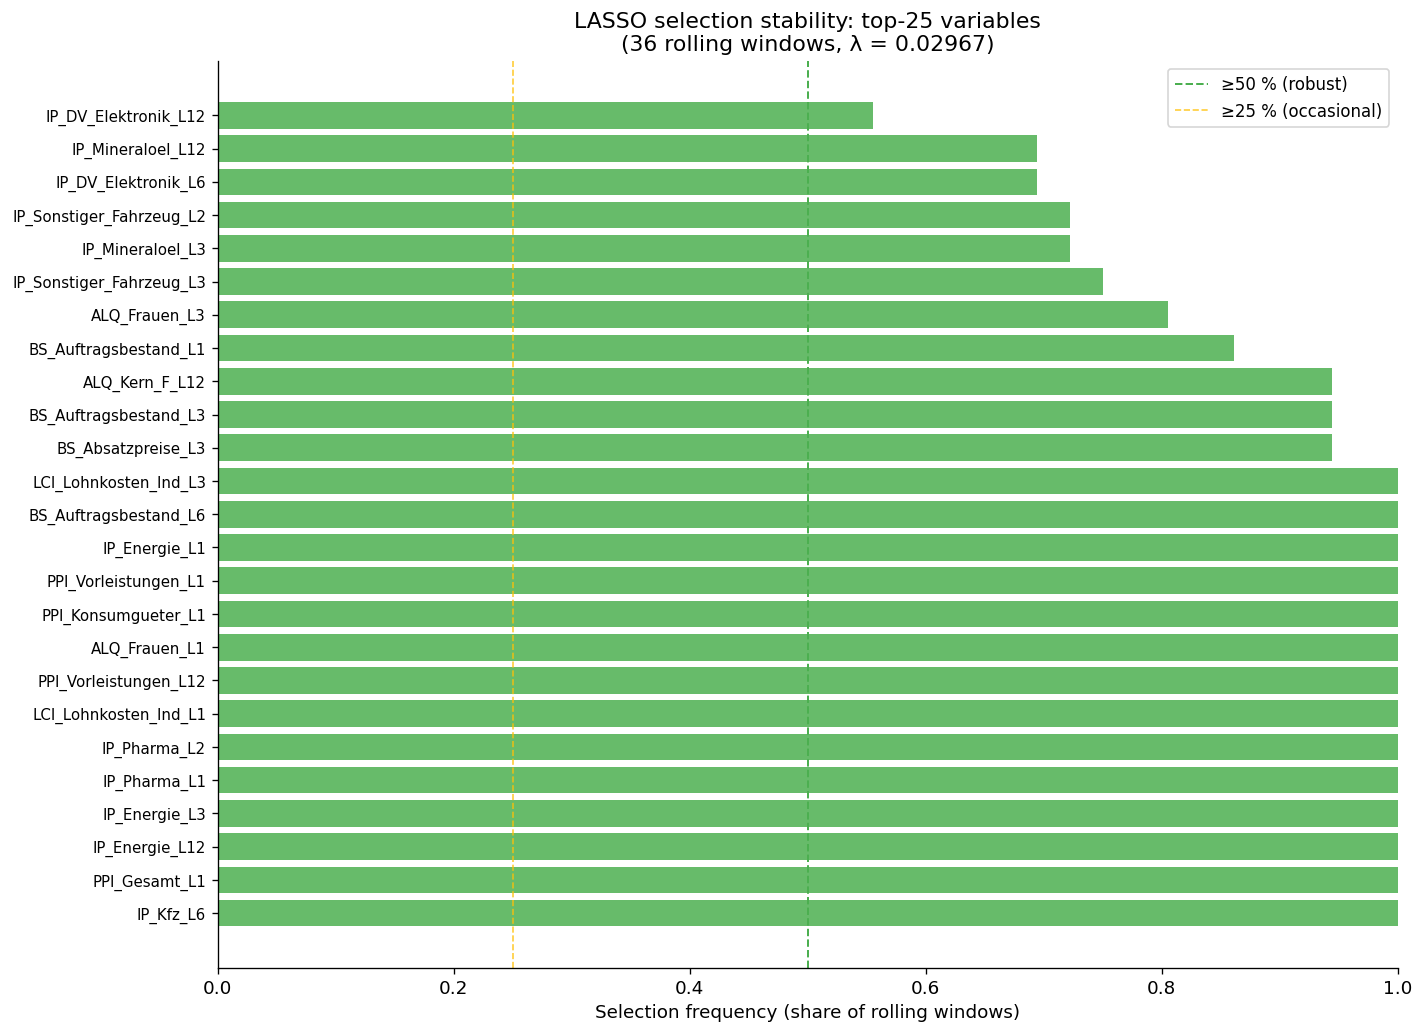

Figure saved: fig_12_selektionsstabilitaet.png


In [28]:
fig_12_selection_stability(sel_ctx["sel_freq"], sel_ctx["n_windows"],
                           models_ctx["lambda_lasso"])

### 4.6.1 Economic interpretation of the selection (Phillips curve, cost-push)

The LASSO selection reflects not only statistical regularisation but can also be
interpreted economically through inflation theory. The predictors fall into five
groups:

| Group | Variables | Theoretical channel |
|--------|-----------|---------------------|
| **PPI** (producer prices) | `PPI_Gesamt`, `PPI_Konsumgueter`, `PPI_Vorleistungen` | Cost-push/pass-through: energy and intermediate-input prices are passed on to consumer prices |
| **LCI** (labour costs) | `LCI_Lohnkosten_*`, `LCI_Loehne_*` | Second-round effects: wage-price spiral (Phillips curve, supply side) |
| **BS** (business climate) | `BS_Konjunkturklima`, `BS_Absatzpreise`, … | Expectations: firms' price expectations anticipate future inflation dynamics |
| **ALQ** (unemployment) | `ALQ_Gesamt`, `ALQ_Kern_*` | Phillips curve (demand side): lower unemployment -> wage pressure -> inflation |
| **IP** (industrial production) | 15 sectors | Supply capacity: output gaps signal capacity utilisation |

The **cost-push hypothesis** (cost-push/Phillips curve) states: in the energy-price-shock regime
(2021-2023), PPI and LCI variables should be selected more often than in the
disinflation phase (2023-2024), because in that episode cost-side rather than demand-side
(ALQ/IP) forces dominated.

In [29]:
from src.evaluation import compute_selection_by_regime
from src.reporting import export_selection_economic

sel_regime_ctx = compute_selection_by_regime(
    X, y, train_end, models_ctx["lambda_lasso"]
)
ctx.update(sel_regime_ctx)
export_selection_economic(sel_regime_ctx)


Regime-dependent selection frequency per economic group (LASSO, λ=0.02967)
  OOS period:    2021-06 - 2024-10  (n=36 windows)
  Shock:         2021-06 - 2023-03 (n=22)
  Disinflation:  2023-04 - 2024-10 (n=14)

                                 Total  Shock  Disinflation
PPI (producer prices/cost-push)  0.335  0.312         0.371
BS (business expectations)       0.200  0.178         0.234
IP (industrial production)       0.200  0.201         0.199
LCI (labour cost/cost-push)      0.172  0.166         0.182
ALQ (labour market/Phillips)     0.112  0.097         0.136

  PPI (producer prices/cost-push): Shock=0.312, Disinfl.=0.371 -> higher in the disinflation
  LCI (labour cost/cost-push): Shock=0.166, Disinfl.=0.182 -> higher in the disinflation
results/selection_economic.csv saved.
results/selection_economic.tex saved.
                                 Total  Shock  Disinflation
PPI (producer prices/cost-push)  0.335  0.312         0.371
BS (business expectations)       0.200  0.178    

**Findings on the economic interpretation of the selection:**

The selection frequencies per economic group show which inflation drivers LASSO
regards as forecast-valuable across the rolling windows. The cost-push hypothesis implies
two expected patterns: (a) **PPI and LCI dominate in the shock regime**, because energy and
intermediate-input price surges are the direct transmission channel to the HICP inflation rate,
and (b) **ALQ and IP lose relative information content in the shock**, because the classical
demand-pull Phillips curve becomes statistically flat during phases of supply-side shocks
(cf. Stock & Watson 2007, Ball & Mazumder 2011).

If the selection frequency of the cost-push variables in the shock regime is indeed higher
than in the disinflation phase, this is an **economic finding**, not an
estimation artefact: LASSO automatically extracts the dominant inflation channel per regime, without
the economist having to specify the structural break ex ante. This state dependence of the
variable selection connects the regularisation approach with the concept of a
**regime-dependent Phillips curve** (cf. Hooper, Mishkin & Sufi 2020, Forbes et al. 2021)
and supports the time-varying predictive ability shown in Chapter 4.5.3 (Giacomini-Rossi).

## 4.7 Multiple forecast horizons

Comparison of model accuracy (RMSE) for h ∈ {1, 3, 6, 12} months ahead. For each horizon,
`build_feature_matrix` is called with `forecast_horizon=h` and λ is re-selected via cross-validation.
The h-step Random Walk forecast is ŷ_t = y_{t-h}.

In [30]:
hor_ctx = compute_horizon_analysis(df_yoy, tscv=config.TSCV)
ctx.update(hor_ctx)

Pre-embargo RMSE loaded from results/horizons_table.csv (compared after the loop).
  h       RW      OLS    Ridge    LASSO (sel)       EN (sel)
-----------------------------------------------------------------


h= 1: RW=0.940  OLS=3.404  Ridge=1.957  LASSO=1.831 ( 29)  EN=1.845 ( 34)


h= 3: RW=1.889  OLS=5.109  Ridge=3.486  LASSO=3.101 ( 11)  EN=3.183 ( 13)


h= 6: RW=2.845  OLS=5.633  Ridge=4.308  LASSO=3.673 (  9)  EN=4.337 ( 24)


h=12: RW=4.593  OLS=5.678  Ridge=4.424  LASSO=4.133 (  5)  EN=4.133 (  5)

RMSE difference embargo CV vs. no embargo (positive Δ = embargo raises RMSE):
    h     ΔLASSO     ΔRidge        ΔEN  Note
  ------------------------------------------------------------
  h= 1: (h=1 unchanged - gap=0, no embargo effect)
  h= 3: ΔLASSO=+0.0000  ΔRidge=+0.0000  ΔEN=+0.0000  (gap=2)
  h= 6: ΔLASSO=+0.0000  ΔRidge=+0.0000  ΔEN=+0.0000  (gap=5)
  h=12: ΔLASSO=+0.0000  ΔRidge=+0.0000  ΔEN=+0.0000  (gap=11)
                 RW       OLS     Ridge     LASSO  LASSO Sel.  Elastic Net  EN Sel.
Horizon h                                                                          
1          0.939820  3.403676  1.957105  1.831237          29     1.845417       34
3          1.889273  5.109417  3.485541  3.101281          11     3.183125       13
6          2.844906  5.632653  4.308298  3.672921           9     4.337247       24
12         4.593448  5.678443  4.423511  4.132955           5     4.132955        5


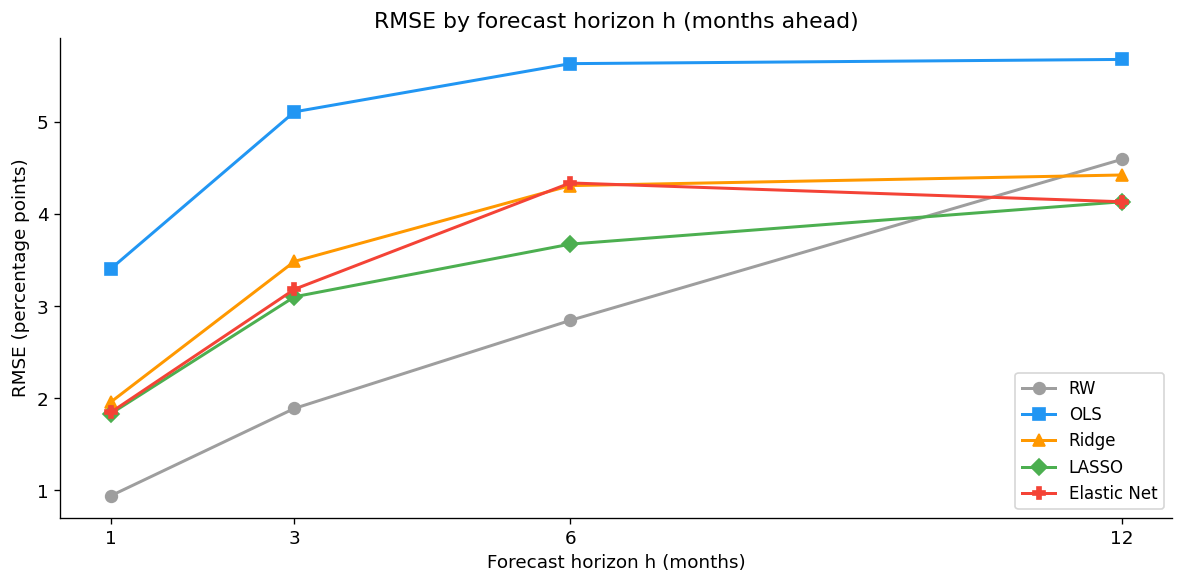

Figure saved: fig_13_horizonte_rmse.png


In [31]:
fig_13_horizons(hor_ctx["df_horizons"])

**Findings on the horizon analysis:**  
The RMSE rises monotonically with the forecast horizon h for all models. Forecasting becomes harder at longer lead times, because the signal-to-noise ratio of the predictors declines. The Random Walk remains the toughest benchmark across all horizons.

The **LASSO selection count falls with h**: at a short horizon (h=1) LASSO still selects a substantial subset of the predictors, but at a long horizon (h=12) only a few variables survive the CV-optimal λ. The macro signal at the annual horizon is so weak that strong regularisation is optimal.

At h=12, **LASSO and Elastic Net give identical results** (same RMSE and same selection count), because `ElasticNetCV` chooses `l1_ratio = 1.0` for this horizon and thus degenerates to a pure L1 penalty. At shorter horizons LASSO and EN differ more in the selection count. The L2 component of the Elastic Net allows several coefficients to stay nonzero for correlated predictors, whereas LASSO picks only one.

*The exact numeric values (RMSE, selection count) can be read from the accompanying table `df_horizons` or from `results/horizons_table.csv`.*

## 5. Coefficient paths and variable selection

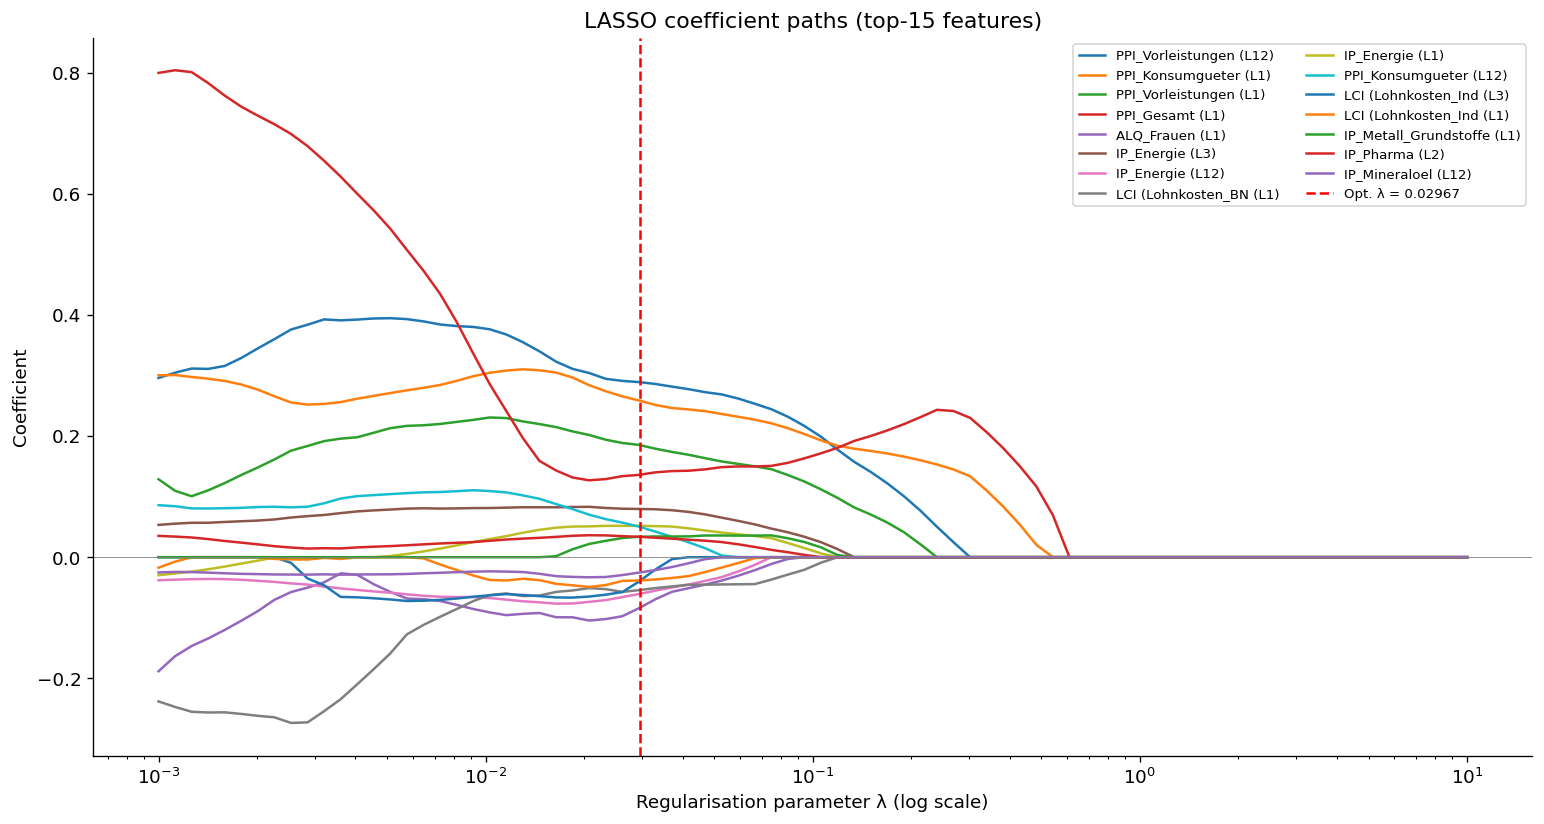

Figure saved: fig_06_lasso_path.png


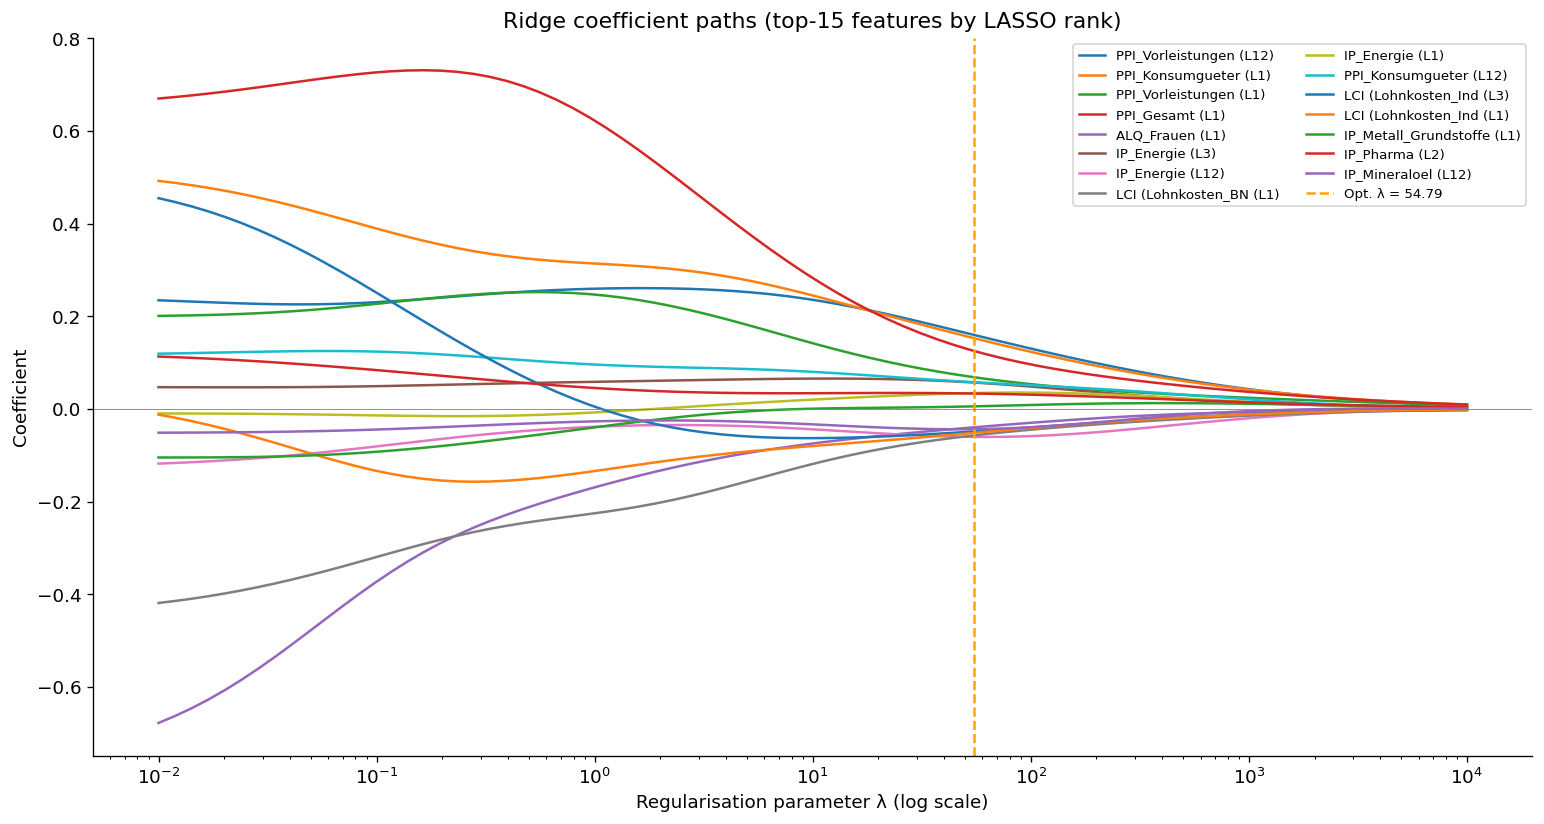

Figure saved: fig_07_ridge_path.png


In [32]:
feat_names = X.columns.tolist()
fig_06_lasso_path(splits["X_train_s"], splits["y_train"], lasso_cv, feat_names)
fig_07_ridge_path(splits["X_train_s"], splits["y_train"], ridge_cv, top_idx, feat_names)

LASSO selects 29 of 155 features:

PPI_Vorleistungen_L12       0.288852
PPI_Konsumgueter_L1         0.258320
PPI_Vorleistungen_L1        0.184968
PPI_Gesamt_L1               0.136150
ALQ_Frauen_L1              -0.083205
IP_Energie_L3               0.079567
IP_Energie_L12             -0.060398
LCI_Lohnkosten_BN_L1       -0.055691
IP_Energie_L1               0.051838
PPI_Konsumgueter_L12        0.049924
LCI_Lohnkosten_Ind_L3      -0.040043
LCI_Lohnkosten_Ind_L1      -0.036933
IP_Metall_Grundstoffe_L1    0.033847
IP_Pharma_L2                0.033680
IP_Mineraloel_L12          -0.025089
ALQ_Kern_F_L12              0.024031
IP_Maschinenbau_L1          0.023508
IP_Kfz_L6                   0.015859
BS_Auftragsbestand_L6       0.015254
LCI_Lohnkosten_BN_L3       -0.014293
IP_Pharma_L1                0.013050
BS_Auftragsbestand_L3       0.012644
BS_Absatzpreise_L3          0.011403
IP_Mineraloel_L3            0.009323
BS_Auftragsbestand_L1       0.005346
LCI_Loehne_BN_L6            0.003145
IP_

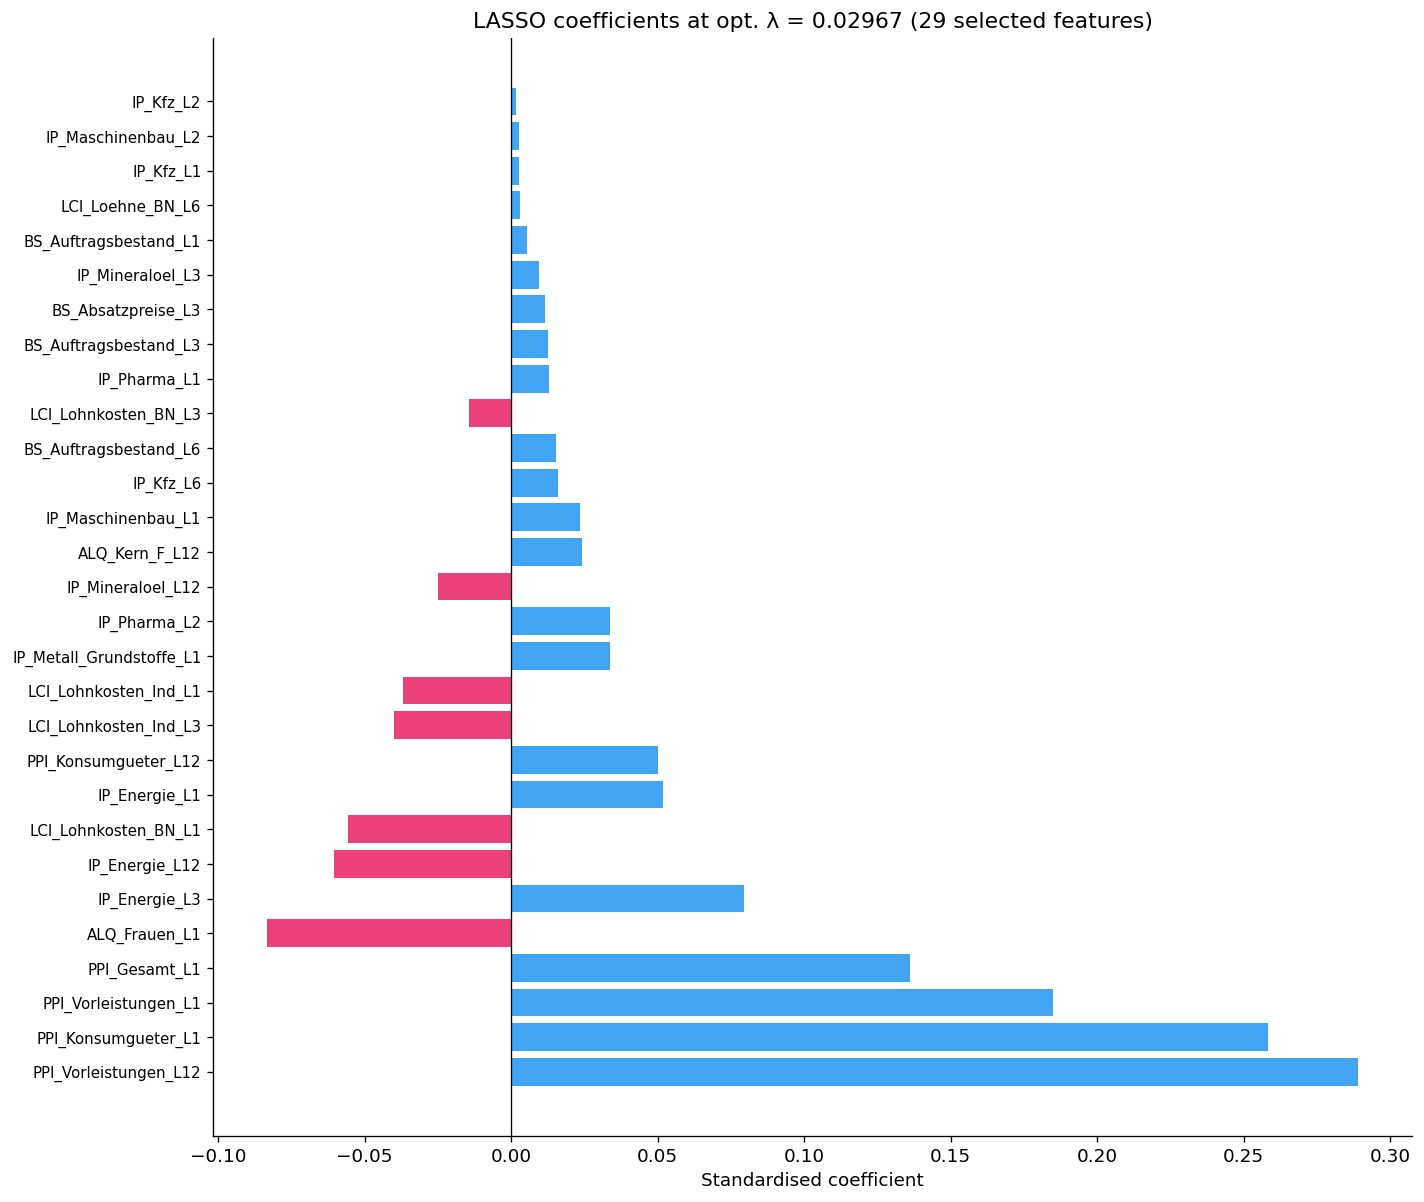


Figure saved: fig_08_lasso_selektion.png


In [33]:
fig_08_lasso_selection(lasso_cv, X)

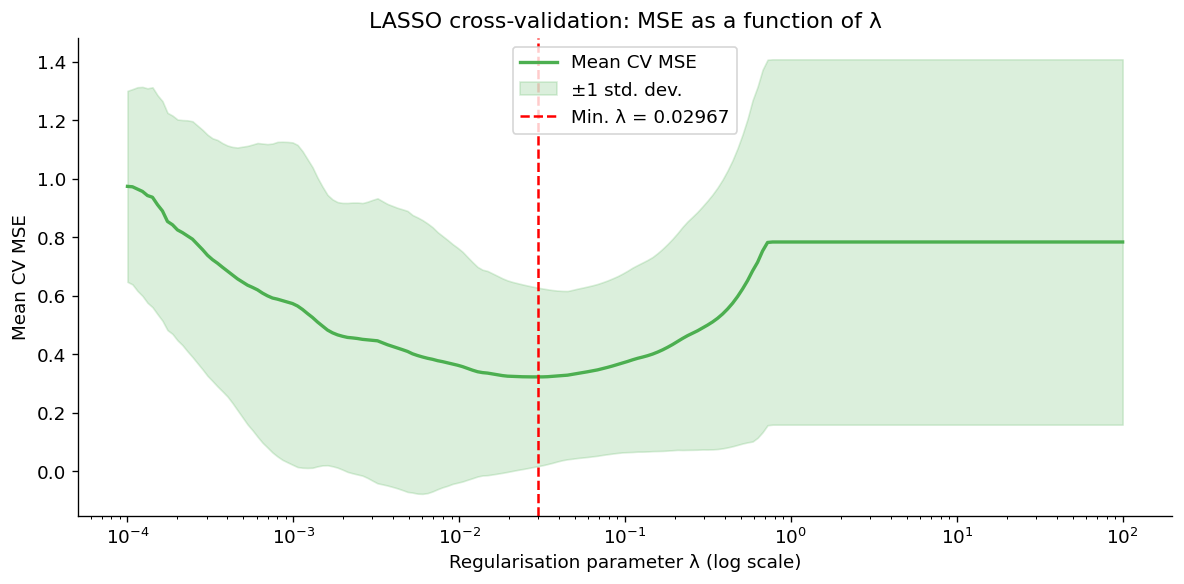

Figure saved: fig_09_lasso_cv_path.png


In [34]:
fig_09_lasso_cv_path(lasso_cv)

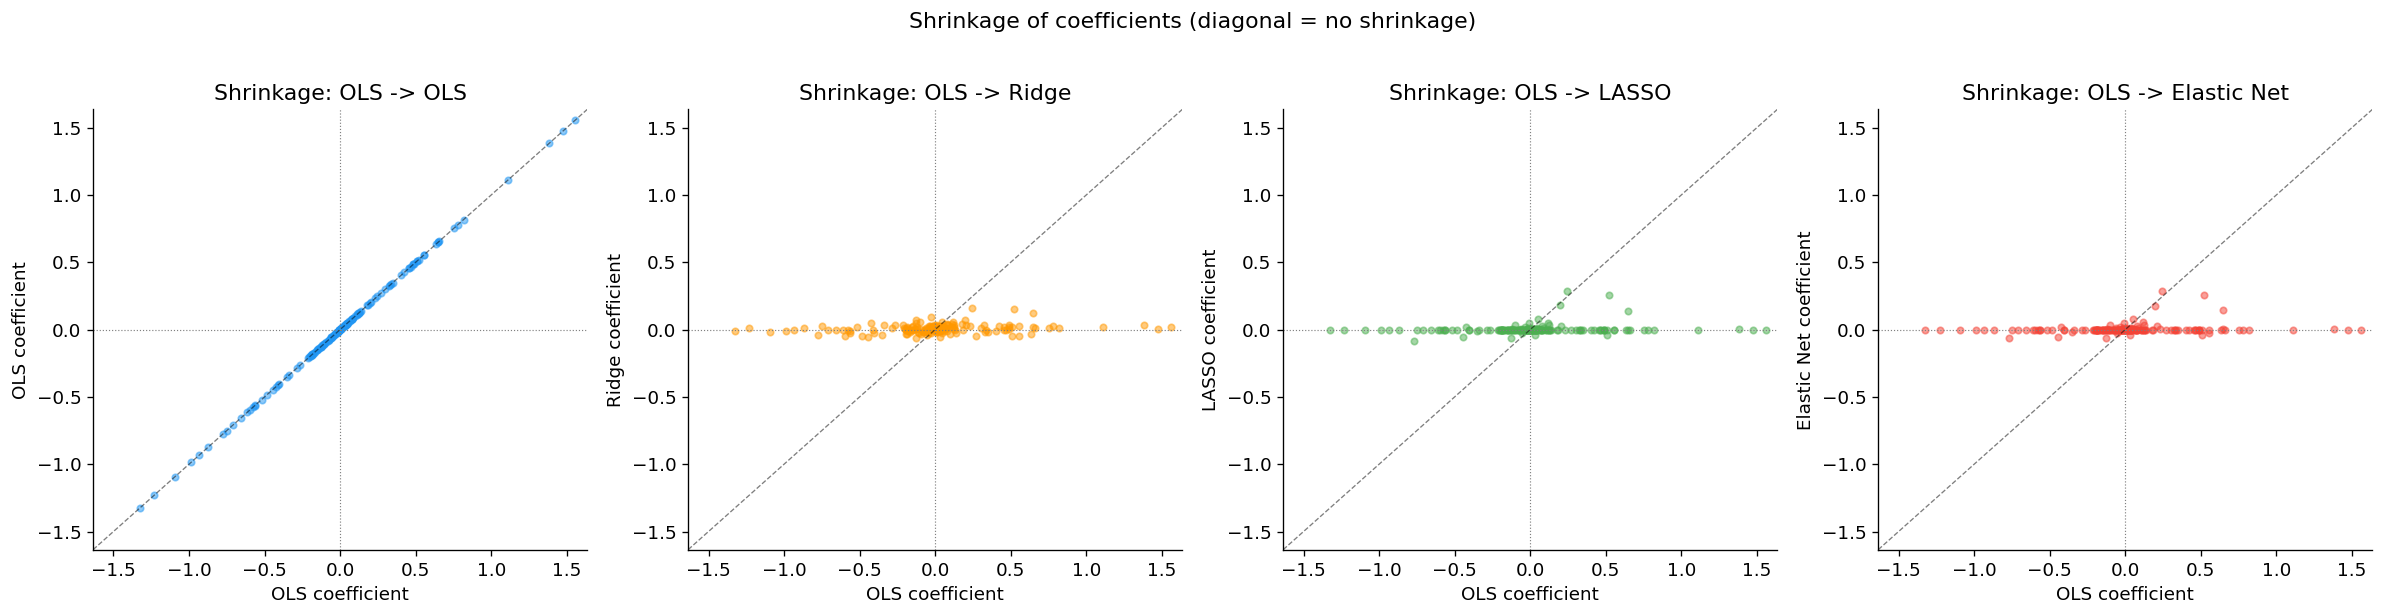

Figure saved: fig_10_shrinkage.png


In [35]:
fig_10_shrinkage(ols, ridge_cv, lasso_cv, enet_cv)

## 6. Interpretation and conclusion

In [36]:
print_summary(ctx)

SUMMARY OF RESULTS
Dataset:    261 months, 155 features
Period:     2002-01 - 2024-10
Test split: 36 months (chronological)

Model             Test-RMSE   RMSE/RW    Test-R²   Coeff.≠0

-- Benchmark ------------------------------------------------------
---------------------------------------------------------------------------
Random Walk          0.9398 1.000 (Ref)     0.8933          -
ADL                  1.0542     1.122     0.8657          5

-- Core comparison: own lags + macro (ceteris paribus) ----------
---------------------------------------------------------------------------
LASSO+HVPI           1.4745     1.569     0.7374          7

-- Illustrative: macro only, no own lags (structurally disadv.) --
---------------------------------------------------------------------------
OLS                  3.4037     3.622    -0.3994        155
Ridge                1.9571     2.082     0.5373        155
LASSO                1.8312     1.948     0.5949         29
Elastic Net          

### Interpretation of the results

**1. Central finding (economically clean, ceteris paribus): macro added value beyond the persistence is zero.**  
The fair comparison is the **lag model (ADL)** - pure HICP own lags, no macro variables - against
**LASSO+HVPI** - the same own lags *plus* all regularised macro predictors:

| Model | Single-split RMSE/RW | Rolling-origin RMSE/RW |
|--------|-------------------:|----------------------:|
| Lag model (ADL) | ≈ 1.12 | ≈ 0.95 |
| LASSO+HVPI       | ≈ 1.47 | ≈ 0.95 |

Adding macro predictors to pure inflation persistence does not reduce accuracy
(rolling origin: identical), but it also does not measurably improve it. The macro added value
is *ceteris paribus* close to zero. Clark-West tests for both nested models: n.s.  
This result is consistent with Atkeson & Ohanian (2001) and Stock & Watson (2007):
structural models and Phillips-curve predictors typically do not beat the naive benchmark in
inflation forecasting.

**2. [Illustrative part] Regularisation fixes the OLS overfitting.**  
At p/n ≈ 0.69 (225 observations, 155 features) and pronounced multicollinearity
(cf. the condition number in Section 2b), OLS is unusable (test-R² = -0.40).
Ridge, LASSO, and Elastic Net stabilise the estimation clearly (test-R² up to 0.77
(Adaptive LASSO) or 0.74 (LASSO+HVPI), 0.59 without own lags). LASSO achieves this with
only 29 of 155 variables and thus provides an interpretable selection.  
*These models are structurally disadvantaged - they lack the strongest single predictor
(HICP lag 1) - and therefore do **not** provide a fair comparison against the Random Walk.*

**3. No macro model beats the naive Random Walk.**  
The Random Walk (ŷ_t = y_{t-1}) has the best test accuracy in the single split with RMSE ≈ 0.94.
In the rolling-origin design, AR and LASSO+HVPI come close to the RW (0.95 and 0.95),
but do not clearly beat it - and across all horizons h ∈ {1, 3, 6, 12} the RW remains
the toughest benchmark.

**Placement in the literature.** The result is consistent with Atkeson & Ohanian (2001) and Stock & Watson (2007): structural models and Phillips-curve predictors typically do not beat the naive benchmark in inflation forecasting.

**Contrast with Medeiros et al. (2021).** Medeiros, Vasconcelos, Veiga & Zilberman (2021, "Forecasting Inflation in a Data-Rich Environment: The Benefits of Machine Learning Methods", Journal of Business & Economic Statistics) find a robust ML forecasting advantage for US CPI in a data-rich environment. Four concrete explanations, linked to our own results, for the **absent ML advantage** in the present German HICP setting:

1. **Test regime (main candidate, cf. Section 4.5.2):** The 2021-2024 test window is dominated by the largest inflation episode in the sample (HICP-YoY up to 11.6 %). For a near-I(1) series, the Random Walk is mechanically almost impossible to beat in such a shock regime. The regime analysis (Section 4.5.2) and the Giacomini-Rossi test (Section 4.5.3) show this quantitatively: relative forecast accuracy collapses in the shock. Medeiros et al. evaluate over broader, calmer out-of-sample periods.

2. **Target variable:** YoY rates carry strong, persistence-loaded autocorrelation through the 12-month cumulation effect, which makes the YoY Random Walk an exceptionally strong benchmark. The absent ML advantage is partly an artefact of the target definition (YoY instead of MoM), not solely a substantive result.

3. **Model class:** Medeiros et al. use random forests and bagging methods that capture nonlinearities and interactions. The present analysis is limited to linear shrinkage methods (Ridge, LASSO, Elastic Net). For regime shifts and nonlinear inflation dynamics (e.g. the energy-price shock), this difference is potentially decisive.

4. **Sample size and signal variance:** The European HICP sample (2002-2024, 261 observations) is shorter and dominated by the zero-lower-bound era (2015-2021) with low inflation variance. A weak training signal reduces the predictive power of the macro variables in the test.

In summary: the null finding of this work does *not* contradict Medeiros et al. but *complements* it - it shows that the ML advantage is context-dependent and is not reproducible in the European, linearly regularised setting with an energy-price-dominated test window.

**Key message:** Regularisation is indispensable for estimating stably in a high-dimensional, collinear predictor space - but the economic forecasting gain over pure persistence remains small.

**Limitations:** Revised rather than real-time data vintages. The test regime (2021-2024) is
substantially shaped by the energy-price shock (cf. the regime analysis, Section 4.5.2, and Giacomini-Rossi, Section 4.5.3),
which limits external validity to other inflation regimes.
Forecast differences from the Random Walk are not statistically detectable at T=36
(DM/CW n.s.).

## 7. Preparation and export

Exports tables as LaTeX fragments (`results/*.tex`) and the data-sources table as CSV + LaTeX for the appendix. Figures are saved automatically at 300 DPI on every `savefig` call (`savefig.dpi = 300` in the rcParams).

In [37]:
export_results_table(models_ctx["results"], splits["y_test"])
export_inference_table(inf_ctx["df_inference"], splits["y_test"])
export_horizons_table(hor_ctx["df_horizons"])
export_sources_table()

results/results_table.tex saved.
\begin{table}
\caption{Forecast models compared: mean RMSE, relative RMSE (RMSE/RW) and $R^2$ on the test set (Jun~2021--Oct~2024). \emph{Benchmark}: random walk and lag model (ADL, HICP own lags only). \emph{Core comparison}: LASSO+HVPI (own lags + macro) - economically sound, as \emph{ceteris paribus} with respect to own lags. \emph{Illustrative}: OLS-Adaptive LASSO without own lags (structurally disadvantaged, show regularisation vs.\ OLS overfitting).}
\label{tab:ergebnisse}
\begin{tabular}{lllrrrrl}
\toprule
 & λ & Train MSE & Test MSE & Test RMSE & RMSE/RW & Test $R^2$ & Coeff.$\neq$0 \\
Model &  &  &  &  &  &  &  \\
\midrule
Random Walk & - & - & 0.8833 & 0.9398 & 1.0000 & 0.8933 & - \\
Lag model (ADL) & - & - & 1.1114 & 1.0542 & 1.1217 & 0.8657 & 5 \\
\midrule
LASSO+HVPI & 0.06368 & - & 2.1741 & 1.4745 & 1.5689 & 0.7374 & 7 / 160 \\
\midrule
OLS & - & 0.0242 & 11.5850 & 3.4037 & 3.6216 & -0.3994 & 155 \\
Ridge & 54.789 & 0.1044 & 3.8303 & 1.9571

## 8. README auto-synchronisation

Regenerates the `Results overview` in `README.md` from the live variables
of this notebook. No manual maintenance of numbers is needed - just run the
notebook, and this block updates the README automatically.


In [38]:
update_readmes(ctx)

/Users/anton/Desktop/SoSe26/Oekonometrie_Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26/README_DE.md OK
/Users/anton/Desktop/SoSe26/Oekonometrie_Seminar/RIDGE-LASSO-Inflation-Econometrics-SS26/README.md OK

README auto-sync complete.
  261 obs. (2002-01-2024-10), 155 features, Test 2021-06-2024-10
  RW 0.9398  |  LASSO 1.8312  |  OLS 3.4037
